# GPU-Accelerated Quantitative Portfolio Optimization with NVIDIA cuOpt™
[![Click here to deploy.](https://brev-assets.s3.us-west-1.amazonaws.com/nv-lb-dark.svg)](https://brev.nvidia.com/)

This notebook introduces NVIDIA's GPU-Accelerated Portfolio Optimization developer blueprint. We use the Mean-CVaR model to solve the problem of portfolio asset allocation. We show step-by-step how to pre-process input data, build the optimization model, solve the problem, and backtest the portfolio performance.

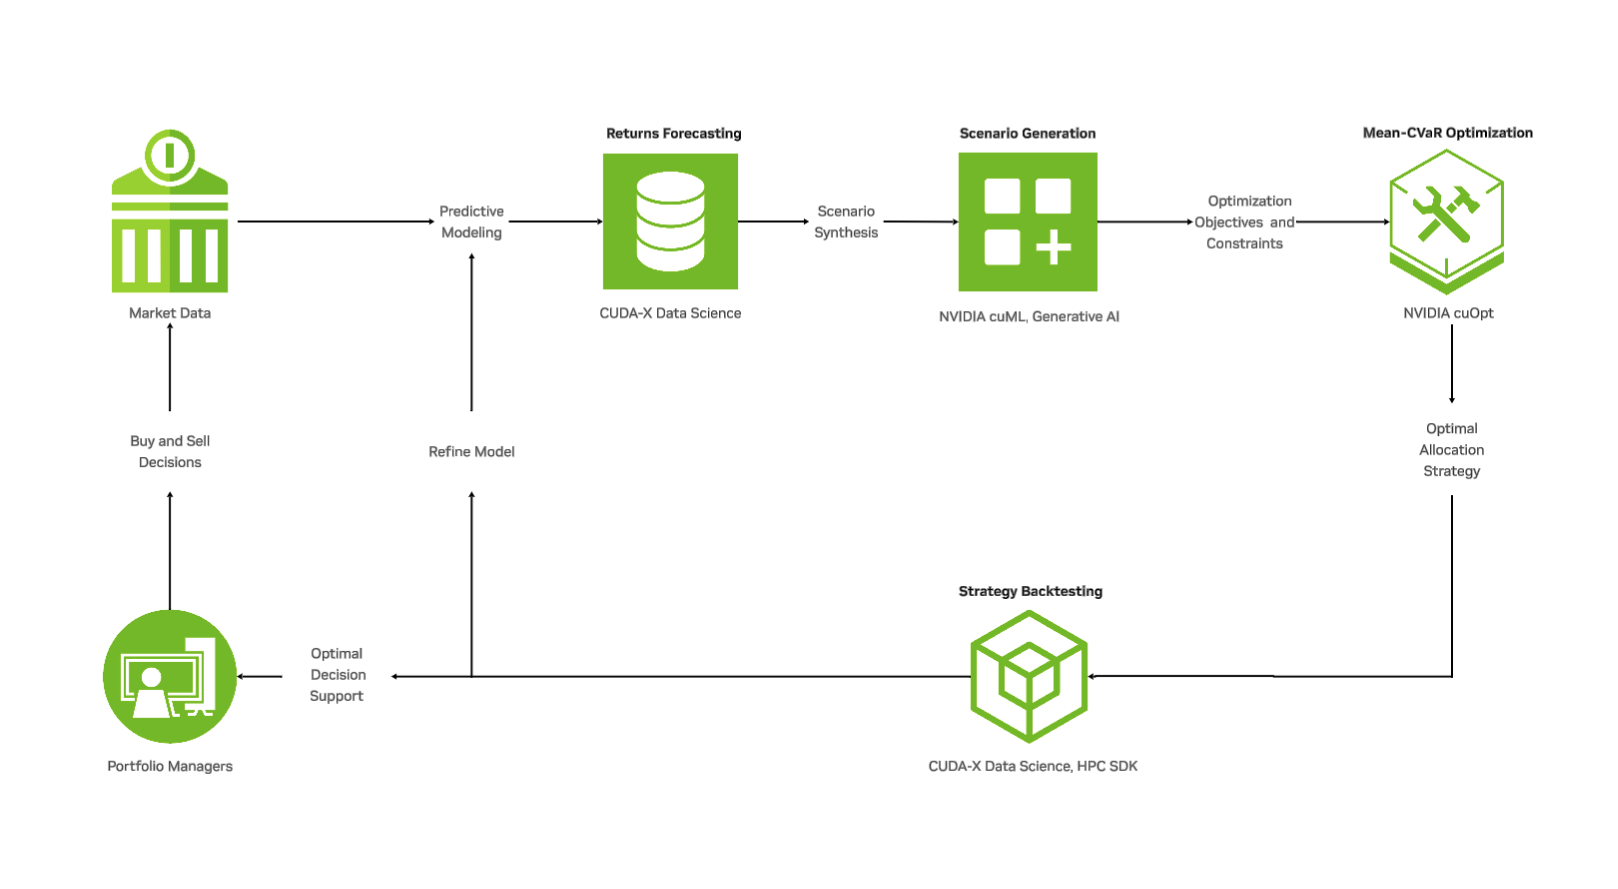

In particular, we will cover the following in this notebook: 
- **Portfolio Optimization Setup** – Clone repository, install dependencies, and configure environment
- **Data-preprocessing** - Calculate daily returns from input price data 
- **Scenario generation** - Use cuML KDE to model returns distribution and generate return scenarios 
- **Model Building** - Build the optimization problem with optional constraints
- **Solving Optimization on GPU** – Call GPU/CPU solvers with customizable settings to solve the problem
- **Backtesting** - Visualize and evaluate optimized portfolio
- **Comparing CPU and GPU Performance** – Evaluate performance solving optimization problem on GPU vs CPU
- **Generating Efficient Frontier** - Create an efficient frontier by solving optimization for different risk aversion levels
- **Backtesting Re-Balancing Strategies** - Re-balance portfolios over time with different strategies

## Table of Contents
---
### Basic Walk-through:

0. [Environment Setup](#environment-setup)
   - Install Dependencies
   - Verify Installation

1. [Portfolio Optimization Setup](#portfolio-optimization-setup)
   - GPU Check
   - Import Libraries

2. [Introduction to Mean-CVaR Optimization](#build-a-mean-cvar-problem)
   - Mathematical Formulation

3. [Data Preprocessing and Model Setup](#data-preprocessing-and-model-setup)
   - Data Preparation
   - Define Problem Parameters
   - Build Mean-CVaR Problem

4. [Solve CVaR Optimization](#solve-cvar-optimization)
   - cuOpt GPU LP Solver
   - CPU Solver Comparison
   - Portfolio Visualization
   - cuOpt GPU MILP Solver

5. [Backtest Portfolio](#backtest-portfolio)
   - Testing Methods
   - Performance Metrics
   - Benchmark Comparison

6. [GPU vs. CPU: Comparison over Different Regimes](#gpu-vs-cpu-comparison-over-different-regimes)
   - Regime Analysis
   - Performance Comparison

7. [Appendix](#appendix)
   - Optional Parameter Constraints
   - cuOpt Python API
---
### Advanced topics: 
1. [Efficient Frontier](#efficient-frontier)

2. [Rebalancing Strategies](#rebalancing-strategies)

   - Percentage change strategy
   - Drift from optimal strategy



---

<a id="environment-setup"></a>
## 0. Environment Setup

Run the cells below to install dependencies and configure the Jupyter kernel.


### Install Dependencies


In [1]:
import subprocess
import re
import os

def detect_cuda_version():
    """Detect CUDA runtime version from nvidia-smi or nvcc."""
    # Try nvidia-smi first (gets driver's CUDA version)
    try:
        result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            match = re.search(r"CUDA Version:\s*(\d+)\.(\d+)", result.stdout)
            if match:
                major = int(match.group(1))
                print(f"✓ Detected CUDA {major}.{match.group(2)} (from nvidia-smi)")
                return major
    except Exception:
        pass
    
    # Fallback to nvcc
    try:
        result = subprocess.run(["nvcc", "--version"], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            match = re.search(r"release (\d+)\.(\d+)", result.stdout)
            if match:
                major = int(match.group(1))
                print(f"✓ Detected CUDA {major}.{match.group(2)} (from nvcc)")
                return major
    except Exception:
        pass
    
    print("⚠ CUDA not detected, defaulting to cu12")
    return 12

CUDA_MAJOR = detect_cuda_version()
CUDA_EXTRA = "cuda12" if CUDA_MAJOR <= 12 else "cuda13"
print(f"→ Will install with extra: {CUDA_EXTRA}")

# Export for use in install cell
os.environ["CUDA_SUFFIX"] = CUDA_EXTRA


✓ Detected CUDA 13.0 (from nvidia-smi)
→ Will install with extra: cuda13


### Install Dependencies


In [2]:
import subprocess

# Get CUDA suffix from environment (set by detection cell)
cuda_suffix = os.environ.get("CUDA_SUFFIX", "cu12")
print(f"Installing with CUDA extra: {cuda_suffix}")

# Install uv and sync with appropriate CUDA extra
subprocess.run("curl -sSf https://astral.sh/uv/install.sh | sh", shell=True, check=True)

install_script = f"""
export PATH="$HOME/.local/bin:$PATH"
cd "$(dirname "$(pwd)")" 2>/dev/null || cd ..
unset VIRTUAL_ENV
uv sync --extra {cuda_suffix}
uv run python -m ipykernel install --user --name=portfolio-opt --display-name "Portfolio Optimization"
"""

subprocess.run(install_script, shell=True, executable="/bin/bash")
print(f"\n✅ Installed with --extra {cuda_suffix}")

Installing with CUDA extra: cuda13


Resolved 201 packages in 5ms
Audited 139 packages in 173ms


Installed kernelspec portfolio-opt in /home/phuo/.local/share/jupyter/kernels/portfolio-opt

✅ Installed with --extra cuda13


### Verify Installation

After running the cell above, **select the `Portfolio Optimization` kernel** from the kernel menu, then run the cell below to verify all packages are installed.

In [1]:
import importlib

packages = ['numpy', 'pandas', 'cvxpy', 'sklearn', 'seaborn', 'cuml', 'cuopt', 'yfinance']

print("Checking packages...\n")
failed = []
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'installed')
        print(f"✓ {pkg:12s} {ver}")
    except ImportError as e:
        print(f"✗ {pkg:12s} FAILED")
        failed.append(pkg)

print(f"\n{'❌ Missing: ' + ', '.join(failed) if failed else '✅ All packages ready!'}")

Checking packages...

✓ numpy        2.2.6
✓ pandas       2.3.2
✓ cvxpy        1.7.3
✓ sklearn      1.7.1
✓ seaborn      0.13.2
✓ cuml         25.10.00
✓ cuopt        25.10.01
✓ yfinance     0.2.66

✅ All packages ready!


---

<a id='portfolio-optimization-setup'></a>
## 1. Portfolio Optimization Setup

Now that the environment is configured, let's verify GPU availability and import the necessary libraries for portfolio optimization.


In [1]:
!nvidia-smi

Tue Dec  2 09:02:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H200                    On  |   00000000:9D:00.0 Off |                    0 |
| N/A   35C    P0            131W /  700W |     565MiB / 143771MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Import Libraries

Import the portfolio optimization modules and other required packages.


In [ ]:
import os
import cvxpy as cp

from cufolio import cvar_optimizer, cvar_utils, utils
from cufolio.cvar_parameters import CvarParameters
from cufolio.settings import (
    ApiSettings,
    KDESettings,
    ReturnsComputeSettings,
    ScenarioGenerationSettings,
)

---

<a id='build-a-mean-cvar-problem'></a>
## 2. Introduction to Mean-CVaR Optimization

The Mean-CVaR model captures the risk-return trade-off, aiming to maximize expected return while minimizing Conditional Value-at-Risk. 

Traditionally, variance of portfolio returns is used as the measure of risk. Here, we use Conditional Value-at-Risk (CVaR) as an alternative risk measure because it provides a more robust assessment of potential tail losses, and allows a data-driven approach to portfolio optimization without making assumptions on the underlying returns distribution. CVaR measures the average worst-case loss of a return distribution. Formally, for a loss random variable L,
$$\text{CVaR} = {E}[L| L \leq \text{VaR}_\alpha (L)]$$
where  $\text{VaR}(L) = \inf\{l: P(L \leq l) \geq \alpha  \}$ is the $\alpha$-quantile of the loss distribution. CVaR is a more appropriate risk measure for portfolios that may contain assets with asymmetric return distribution - it has replaced Value-at-Risk(VaR) in Basel III market-risk rules; Mathematically, CVaR is a coherent risk measure—satisfying subadditivity, translation invariance, positive homogeneity, and monotonicity—which aligns with the diversification principles. Moreover, it has a computationally tractable transformation as a scenario-based optimization: for confidence level $\alpha$, the CVaR of portfolio ${w}$ can be written in abstract form as 
$$\text{CVaR}({w}) = \min_t\left\{t + \frac{1}{1-\alpha}\sum_{\omega \in \Omega}p(\omega)\max \{\text{loss}({w},\omega) - t, 0\}\right\}, $$
where $\Omega$ is the probability space of returns scenarios and $p(\omega)$ is the probability of a particular scenario $\omega \in \Omega$. Intuitively, this expression represents the portfolio’s average loss below the $\alpha$-quantile of all return scenarios. This scenario-based formulation makes CVaR more robust regardless whether the asset returns distribution is Gaussian or not. When we use linear loss, i.e. $\text{loss}(w,\omega) = -R(\omega){w}$, with $R$ as the return scenarios matrix of size (num_scenarios, num_assets),  the minimization of the CVaR can be transformed into a linear program by replacing the $\max\{\cdot,0\}$ non-negative operator with an auxiliary variable ${u}$: 

\begin{align*}
\text{minimize} \; \quad & t + \frac{1}{1-\alpha}{p}^\top {u},\\
\text{subject to} \quad &{u} +t \geq -R^\top {w},\\
&u\geq 0
\end{align*}



Then, we add constraints to model real-world trading limitations:
- Concentration limits on single assets
- Amount invested in risk-free assets (cash)
- Investment budgets
- Leverage constraints
- Turnover from an existing portfolio
- Cardinality constraints (maximum number of assets allowed in the portfolio)


The mathematical formulation of the problem is given as follows: 
\begin{align*}
\text{maximize } \quad &\mu^\top {w} - \lambda_{\text{\scriptsize risk}}\left(t + \frac{1}{1-\alpha}p^\top {u}\right)\\
\text{subject to} \quad &{u} +t \geq -R^\top {w}, \, u \geq 0 \quad \text{ (CVaR)}\\
& \sum_i w_i + c = 1\quad \text{(self-financing)}\\
& w_i^{\text{\scriptsize min}} \leq w_i \leq w_i^{\text{\scriptsize max}}, \forall i \quad \text{ (concentration)}\\
& c^{\text{\scriptsize min}} \leq c \leq c^{\text{\scriptsize max}} \quad \text{ (cash)}\\
& L= \Vert {w} \Vert_1 \leq L^{\text{\scriptsize limit}} \quad\text{ (leverage)}\\
& T = \Vert {w} - {w}_{\text{\scriptsize pre}}\Vert_1 \leq T^{\text{\scriptsize limit}}\quad \text{ (turnover)}
\end{align*}

## 3. Data Preprocessing and Model Setup
<a id='data-preprocessing-and-model-setup'></a>

We start with an example using a 397-stock subset of the S&P 500 stocks. We aim to build a long-short portfolio that maximizes risk-adjusted returns while meeting custom trading constraints. 

### 3.1 Data Preparation

We load closing prices from `2021-01-01` to `2024-01-01` and compute daily log‐returns.

Key Components:

- Historical Dataset (`data_path`): CSV file with adjusted closing prices.
- Regime Information (`regime_dict`): select the market regime 
- Computation Setting (`returns_compute_settings`): 
    - type of returns to compute "LOG", "NORMAL"
    - frequency: dault to 1 - daily returns



#### Disclaimer
*Each user is responsible for checking the content of datasets and the applicable licenses and determining if suitable for the intended use.*

In [4]:
# User inputs for S&P 500 example
dataset_name = "sp500"
dataset_format = "csv"
data_path = f"../data/stock_data/{dataset_name}.{dataset_format}"

# Download data if not exists
if not os.path.exists(data_path):
    utils.download_data(data_path)

In [ ]:
# Set date range and file path
scenario_name = "recent" 
time_range = ("2021-01-01", "2024-01-01")

# Define the regime for this example
regime_dict = {"name": scenario_name, "range": time_range}

# Define the settings for returns computation
returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)

# Compute returns from price data
returns_dict = utils.calculate_returns(
    data_path,
    regime_dict,
    returns_compute_settings
)

### 3.2 Scenario Generation
Assume the return distribution is stationary over the optimization period and use historical returns to approximate future ones.
In particular, we use `cuml.KDE` on GPU or `sklearn.KDE` on CPU to fit return distribution and sample scenarios. Also support fitting a Multivariate Gaussian distribution and sampling from it. One can configure the scenario generation step by setting `scenario_generation_settings`.


In [ ]:
# Define the settings for scenario generation
scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,  # Number of return scenarios to simulate
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Generate return scenarios from KDE
returns_dict = cvar_utils.generate_cvar_data(
    returns_dict,
    scenario_generation_settings
)

### 3.3 Define Optimization Parameters
We define a `CvarParameters` object to encapsulate key constraints and settings for our portfolio optimization pipeline. This object configures the Mean-CVaR model with both required and optional parameters:

Required parameters: Settings like `w_min`, `w_max`, `risk_aversion`, `confidence`, `num_scen`, and `fit_type` must be specified to establish the basic optimization framework.

Optional constraints: Parameters such as `T_tar` (turnover constraint), `cvar_limit` (maximum CVaR threshold), and `cardinality` (portfolio size limit) are optional. Setting any of these to a non-`None` value will add the corresponding constraint to the Mean-CVaR model.

In [7]:
# Define CVaR optimization parameters for the S&P 500 example
cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95  # CVaR confidence level (alpha)
)

### 3.4 Build Mean-CVaR Problem
We take the processed data `returns_dict` and the problem parameters `cvar_params` and formulates the problem `cvar_problem`. 


In [8]:
# Instantiate CVaR optimization problem for the S&P 500 example
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params
)

---

<a id='solve-cvar-optimization'></a>
## 4. Solve CVaR Optimization

### 4.1 cuOpt GPU LP Solver
We then call the cuOpt LP solver and returns the optimized portfolio. One may also provide customized configurations to the cuOpt LP solver including solver mode, accuracy, etc. 

cuOpt LP solver supports four solve methods: choose one of the following by setting `solver_method`: 
1. PDLP algorithm has three solver modes: choose one of the following by setting `solver_mode`:
    - "Stable2": balance speed and accuracy
    - "Methodical1": prioritize accuracy
    - "Fast1": prioritize speed

2. Dual Simplex
3. Barrier Method
4. Concurrent: runs all three algorithms and return the fastest.

For details, see cuOpt documentation: https://docs.nvidia.com/cuopt/user-guide/latest/introduction.html.


In [9]:
# GPU solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "solver_method": "PDLP", 
                       "time_limit":15, 
                       "optimality": 1e-4
                       }

# Solve on GPU
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)

Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter absolute_dual_tolerance to 1.000000e-04
Setting parameter relative_dual_tolerance to 1.000000e-04
Setting parameter absolute_primal_tolerance to 1.000000e-04
Setting parameter relative_primal_tolerance to 1.000000e-04
Setting parameter absolute_gap_tolerance to 1.000000e-04
Setting parameter relative_gap_tolerance to 1.000000e-04
Setting parameter time_limit to 1.500000e+01

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002536 (0.2536%)
CVaR (95%):          0.025251 (2.5251%)
Objective Value:     -0.001427

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.4183 seconds
CVXPY API Overhead:  

In [10]:
gpu_results

regime          recent
solver           CUOPT
solve time    0.521604
return        0.002536
CVaR          0.025251
obj          -0.001427
dtype: object

### 4.2 Solve on CPU solver
Using CVXPY as the modeling API, we can easily change to any CPU solver supported on CVXPY to solve the same problem and compare the performance. Just change the solver in the solver settings dictionary.

In [ ]:
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=ApiSettings(api="cvxpy")
)

# CPU solver settings
cpu_solver_settings = {"solver":cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4}

# Solve on CPU
cpu_results, cpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cpu_solver_settings)


CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002531 (0.2531%)
CVaR (95%):          0.025260 (2.5260%)
Objective Value:     -0.001443

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.6426 seconds
CVXPY API Overhead:  0.2734 seconds
Solve Time:          24.4407 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (10 assets)
-------------------------
LLY         0.306 ( 30.62%)
NVDA        0.171 ( 17.08%)
MCK         0.145 ( 14.50%)
IRM         0.123 ( 12.30%)
JBL         0.105 ( 10.55%)
STLD        0.089 (  8.89%)
PWR         0.082 (  8.23%

In [13]:
# Compare results between GPU and CPU solvers
utils.compare_results(gpu_results, cpu_results)


SOLVER COMPARISON
Solver          Solve Time (s)  Objective    Return     CVaR      
-----------------------------------------------------------------
cuOpt (GPU)     0.3136          -0.001410    0.002552   0.025887  
CLARABEL (CPU)  64.2751         -0.001409    0.002552   0.025908  

Objective Differences:
cuOpt (GPU) vs CLARABEL (CPU): 0.00000119



### 4.3 Optional: Visualize Optimized Portfolio

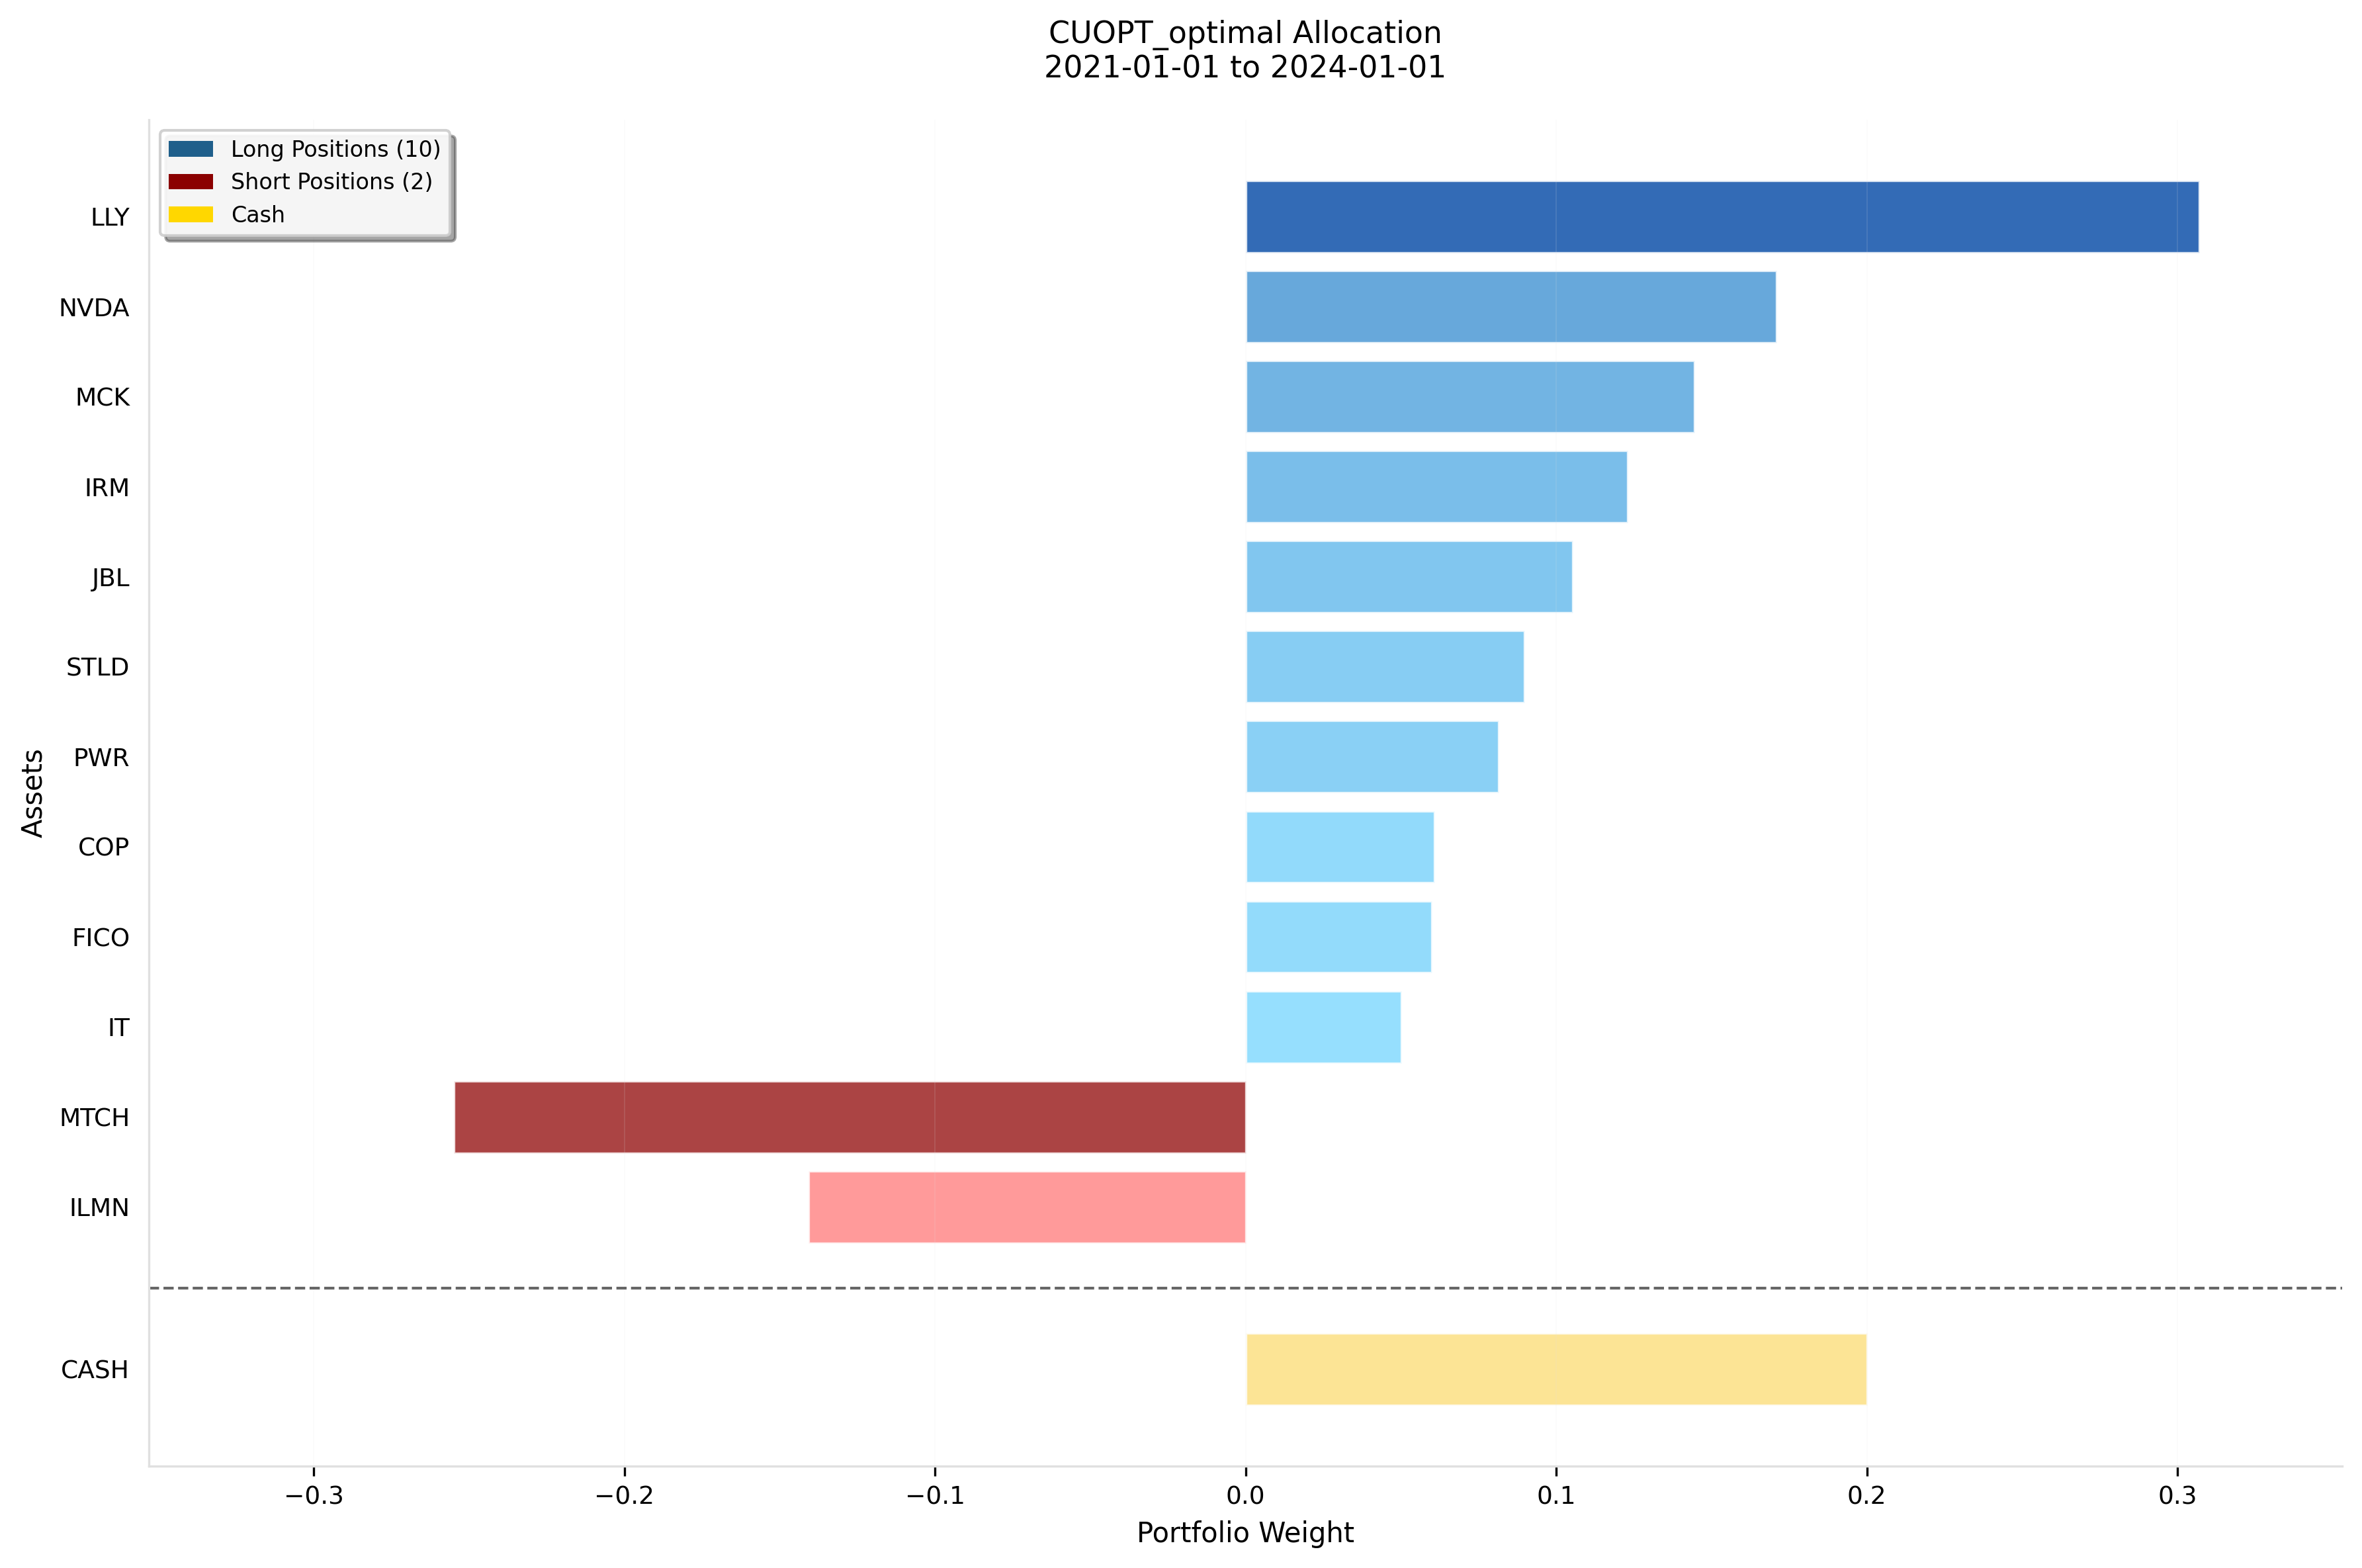

In [12]:
# Plot portfolio
ax = gpu_portfolio.plot_portfolio(show_plot = True, min_percentage = 1)

### 4.4 Adding Cardinality Constraint: Mixed-Integer Linear Program 

A **cardinality constraint** limits the maximum number of assets held in the portfolio, promoting sparsity and reducing transaction costs. This constraint transforms the problem into a **Mixed-Integer Linear Program (MILP)** because it requires binary decision variables to track whether each asset is included.

**Mathematical Formulation:**

We introduce binary variables $y_i \in \{0,1\}$ for each asset $i$, where:
- $y_i = 1$ if asset $i$ is held in the portfolio (i.e., $w_i \neq 0$)
- $y_i = 0$ otherwise

The cardinality constraint is then:
$$\sum_{i=1}^{N} y_i \leq K$$
where $K$ is the maximum number of assets allowed. To link the binary variables with the continuous weights, we add:
$$w_i^{\min} \cdot y_i \leq w_i \leq w_i^{\max} \cdot y_i, \quad \forall i$$

This ensures that $w_i = 0$ when $y_i = 0$, and $w_i$ can take non-zero values only when $y_i = 1$. The presence of integer decision variables $y_i$ makes this a MILP.

The complete problem can be written as follows:

\begin{align}
\text{max: } &\mu^\top {w} - \lambda_{risk}\left(t + \frac{1}{1-\alpha}p^\top {u}\right),\\
\text{subject to: } & {1}^\top {w} = 1,\\
&{u} \geq -R^\top {w} - t,\\
& {w}^{\min} \circ {y} \leq {w} \leq {w}^{\max} \circ {y}, c^{\min} \leq c \leq c^{\max},\\
& L= \Vert {w} \Vert_1 \leq L^{tar},\\
& T = \Vert {w} - {w}_{b}\Vert_1 \leq T^{tar},\\
& \sum{{y}_i} \leq K,\\
&{y}_i \in \{0,1\}^N.
\end{align}

**Model Set-Up:** 

To set up a MILP problem, we just need to set the `cardinality` to an integer number (max number of assets allowed in the portfolio) when instantiating the `CvarParameters` class. cuOpt offers MILP solvers with a GPU-accelerated heuristics algorithm and a CPU branch-and-cut algorithm. Since MILPs are much challenging to solve in general, we should expect a longer solve time. After solving, one can verify that the number of assets in the portfolio is indeed less than or equal to the cardinality constraint. 


In [21]:
# Define CVaR optimization parameters for the S&P 500 example
milp_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality=10,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# Instantiate the MILP problem
milp_cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=milp_cvar_params
)

# cuOpt MILP solver settings
gpu_solver_settings = {"solver": cp.CUOPT, 
                       "verbose": False, 
                       "time_limit":200, 
                       "mip_absolute_tolerance": 1e-4
                       }

# Solve the MILP problem
milp_results, milp_portfolio = milp_cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)

MIXED-INTEGER LINEAR PROGRAMMING (MILP) SETUP
Cardinality Constraint: K ≤ 10 assets
Setting parameter log_to_console to false
Setting parameter mip_absolute_tolerance to 1.000000e-04
Setting parameter time_limit to 2.000000e+02

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              397
Confidence Level:    95.0%
Cardinality Limit:   10 assets

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002559 (0.2559%)
CVaR (95%):          0.026331 (2.6331%)
Objective Value:     -0.001435

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.2639 seconds
CVXPY API Overhead:  0.2181 seconds
Solve Time:          27.2941 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-0

## 5. Backtest Portfolio
<a id='backtest-portfolio'></a>

The `portfolio_backtester` evaluates portfolio performance against historical data and benchmarks. It supports multiple testing methods and calculates comprehensive performance metrics:

**Testing Methods:**
- **Historical**: Uses actual historical return data
- **KDE Simulation**: Generates scenarios using Kernel Density Estimation
- **Gaussian Simulation**: Generates scenarios from multivariate normal distribution

**Performance Metrics:**
- **Sharpe Ratio**: Risk-adjusted return relative to volatility (annualized)
- **Sortino Ratio**: Return relative to downside deviation (annualized)
- **Maximum Drawdown**: Largest peak-to-trough decline

**Benchmarking:** By default, compares against an equal-weight portfolio. Custom benchmarks can also be provided.

The backtester visualizes cumulative returns over time and allows comparison between the optimized portfolio and benchmark strategies.

The `cut_off_date` marks the boundary between training data used for optimization and test data used for out-of-sample evaluation. One can test whether the optimized portfolio is robust to potential regime shifts. 

In [22]:
# Define test regime and calculate test returns
test_regime_dict = {"name": "test_recent", "range": ("2023-09-01", "2024-07-01")}
test_returns_dict = utils.calculate_returns(data_path, test_regime_dict, returns_compute_settings)

# Backtest settings
test_method = "historical"
risk_free = 0.0

,returns,cumulative returns,mean portfolio return,sharpe,sortino,max drawdown
portfolio name,,,,,,
CUOPT_optimal,"[0.0035103278949567577, 0.0010056711214110902,...","[1.0035164963115315, 1.0045262115073383, 1.013...",0.002771,3.093438,5.448196,0.08308
AMZN-JPM,"[-0.0064417289014207305, -0.010386334705014998...","[0.9935789745549939, 0.9833127373471416, 0.994...",0.001345,1.628412,2.553817,0.136418
AAPL-MSFT,"[0.009376115317883675, -0.01179679161502003, -...","[1.0094202087878543, 0.9975822511770992, 0.983...",0.000458,0.72608,1.085632,0.073053
NKE-MCD,"[-0.00916418488056512, -0.009068958908961732, ...","[0.9908776782835054, 0.9819320743044023, 0.983...",-0.000213,-0.389702,-0.565025,0.131192


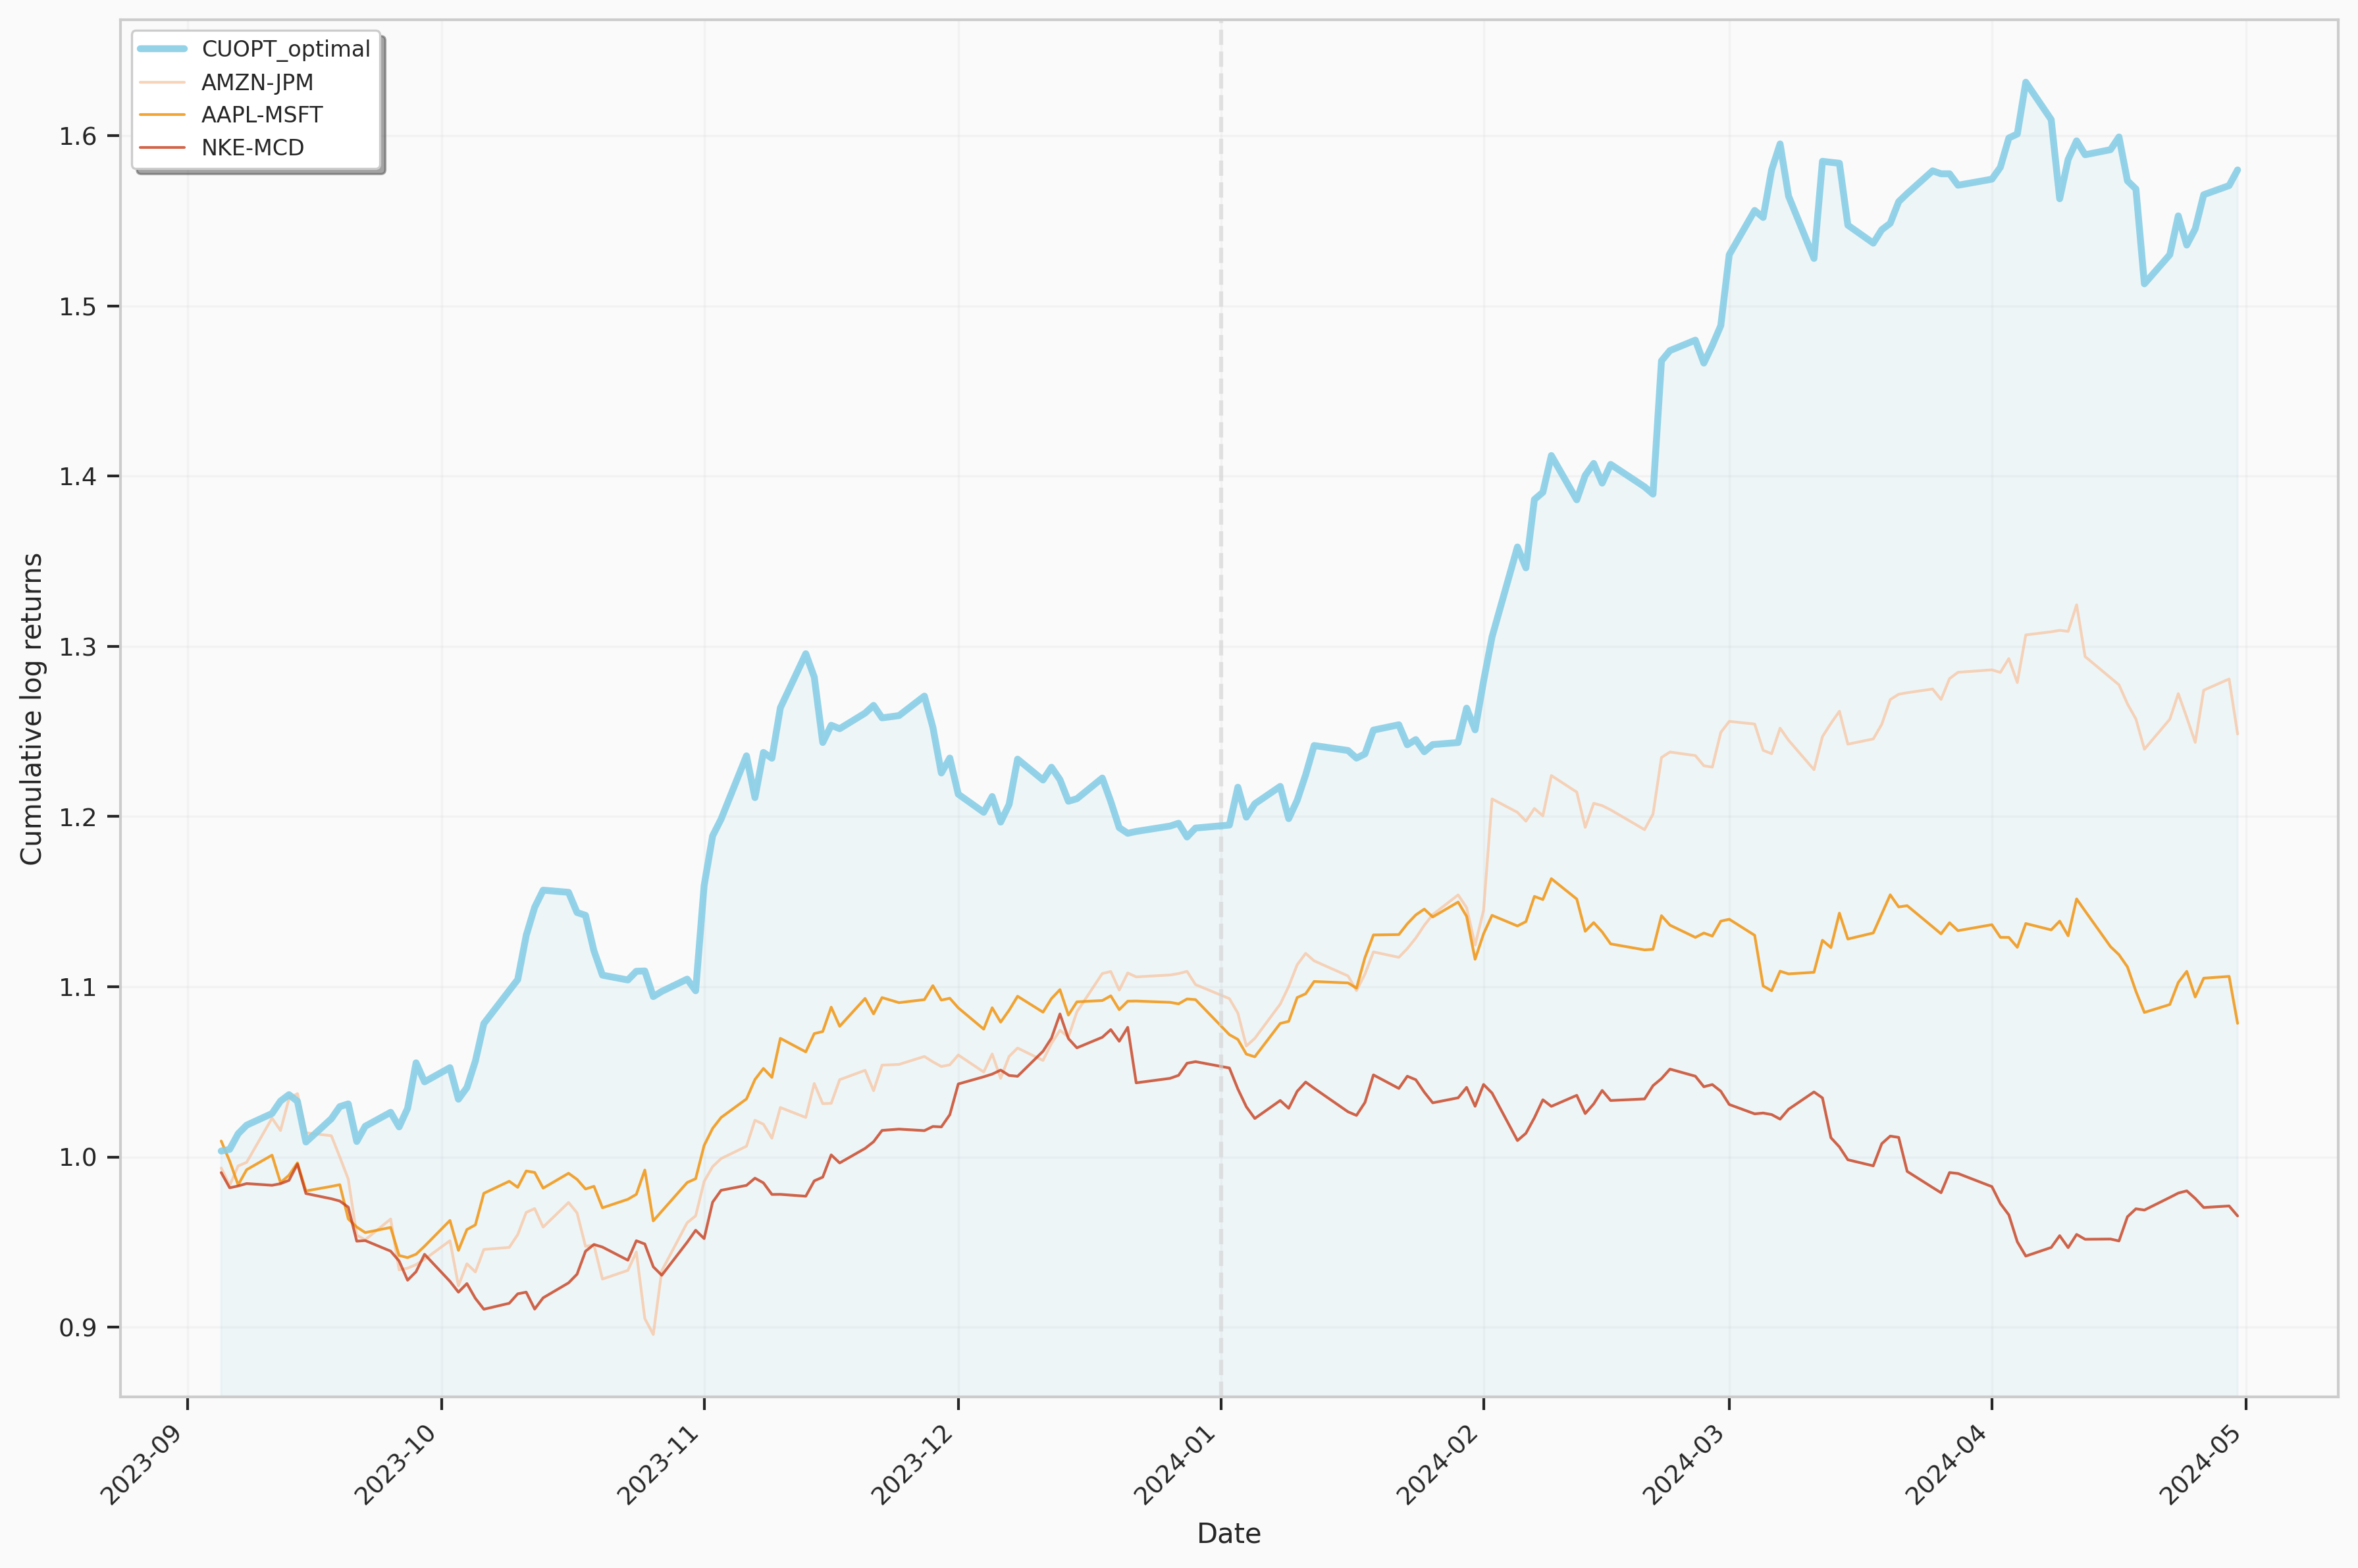

In [23]:
from cufolio import backtest

# (Optional) Compare results between optimized portfolio and user-defined portfolios
portfolios_dict = {'AMZN-JPM':({'AMZN': 0.72, 'JPM': 0.18}, 0.1),\
                   'AAPL-MSFT': ({'AAPL': 0.29, 'MSFT': 0.61}, 0.1),\
                   'NKE-MCD': ({'MCD': 0.65, 'NKE': 0.25}, 0.1)}

benchmark_portfolios = cvar_utils.generate_user_input_portfolios(portfolios_dict, test_returns_dict)

# Uncomment the following lineto use equal-weight benchmark portfolio
# benchmark_portfolios = None 

# Set cut-off date for backtest visualization
cut_off_date = regime_dict["range"][1]

# Create backtester and run backtest
backtester = backtest.portfolio_backtester(gpu_portfolio, test_returns_dict, risk_free, test_method, benchmark_portfolios = benchmark_portfolios)

backtest_result,_ = backtester.backtest_against_benchmarks(plot_returns=True, cut_off_date=cut_off_date)

backtest_result

Combined plot saved: ../results/backtest/combined_cuopt_optimal_historical_analysis.png


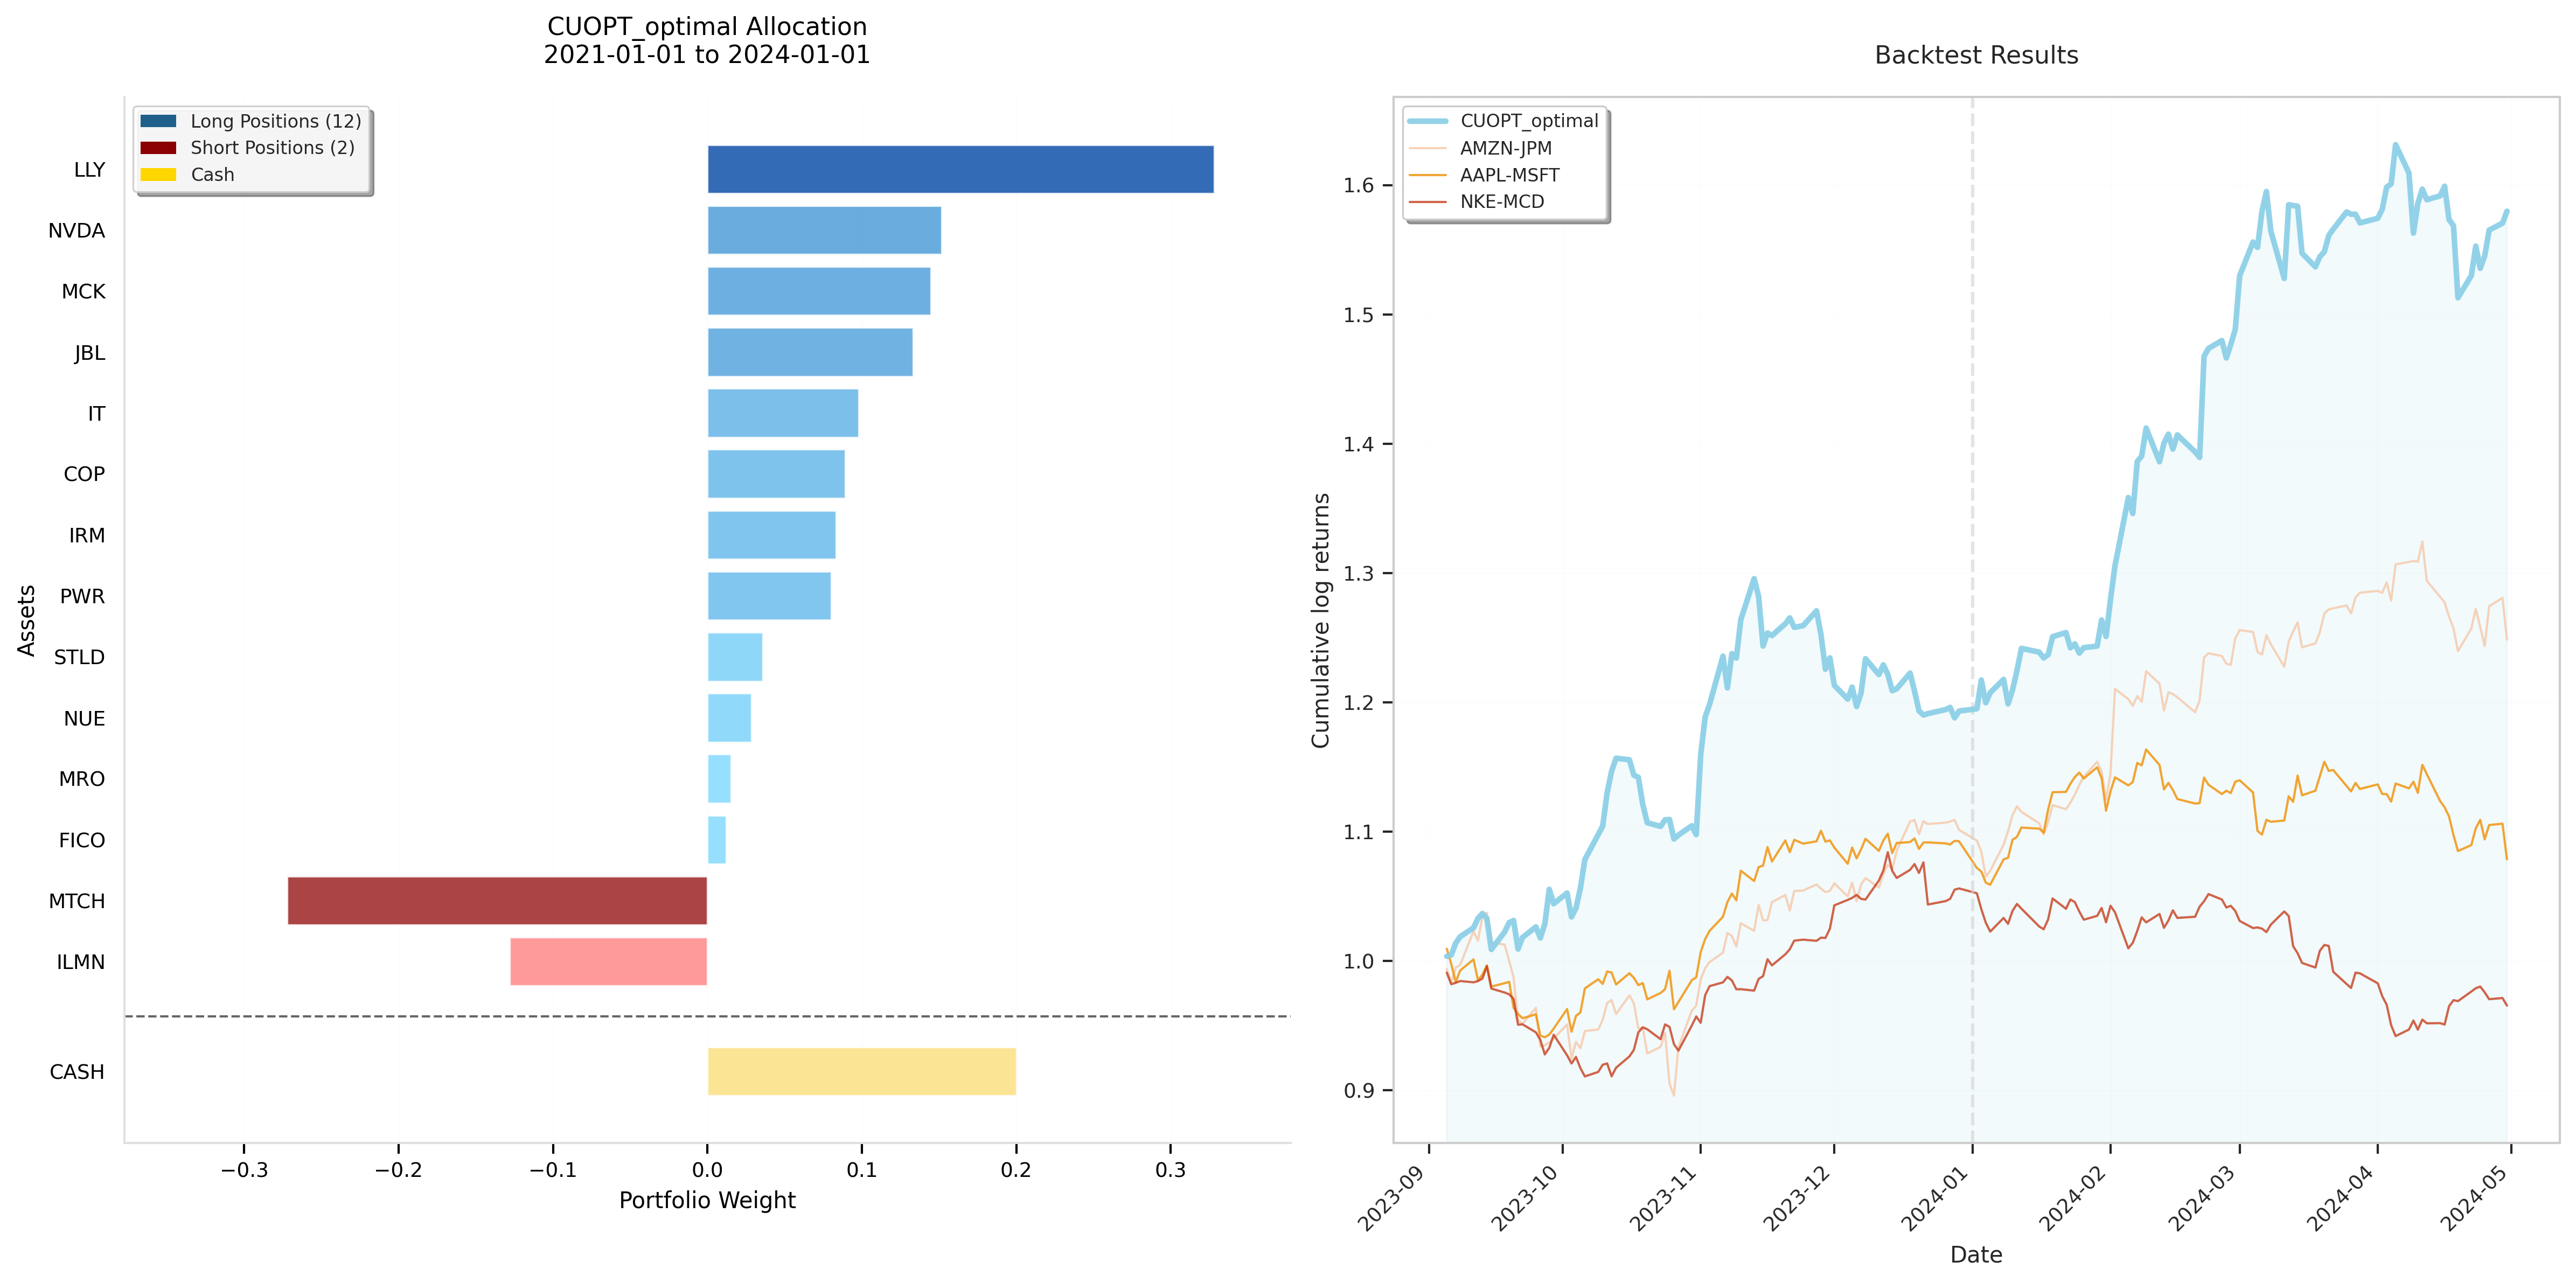

In [24]:
# Plot portfolio and backtest results side by side
utils.portfolio_plot_with_backtest(portfolio=gpu_portfolio, \
                                   backtester=backtester, \
                                   cut_off_date=cut_off_date, \
                                   backtest_plot_title="Backtest Results", \
                                   save_plot = True, \
                                   results_dir = "../results/backtest")

## 6. GPU vs. CPU: Comparison over Different Regimes
<a id='gpu-vs-cpu-comparison-over-different-regimes'></a>

To further compare the performance of cuOpt GPU solver vs. CPU solvers, we can compare CPU vs. GPU performance over solving the same problems over different market regimes. The function `utils.optimize_market_regimes` generates Mean-CVaR optimization problems iteratively over different regimes from `regime_comparison_selected_dict`, solve each problem using all the solvers specified in `solver_settings_list`, and returns a dataframe of results. 

In [ ]:
# CVaR parameters for regime comparison
regime_comparison_cvar_params = CvarParameters(
    w_min={"NVDA":0.1, "others": -0.3}, w_max={"NVDA": 0.6, "others": 0.4},  # Asset weight allocation bounds
    c_min=0.0, c_max=0.2,  # Cash holdings bounds
    L_tar=1.6, T_tar=None,  # Leverage and turnover (None for this example)
    cvar_limit=None,  # Max CVaR (None = unconstrained for this example)
    cardinality = None,  # Cardinality constraints
    risk_aversion=1,  # Risk aversion level
    confidence=0.95,  # CVaR confidence level (alpha)
)

# User inputs for regime comparison
regime_comparison_dataset_name = "sp500"
regime_comparison_num_scen = 20000
regime_comparison_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
regime_comparison_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=regime_comparison_num_scen,
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Prepare output directory and file name
regime_comparison_output_folder = "../results/regime_results"
os.makedirs(regime_comparison_output_folder, exist_ok=True)
regime_comparison_results_csv_path = os.path.join(
    regime_comparison_output_folder,
    f"both_results_{regime_comparison_dataset_name}_{regime_comparison_num_scen}.csv"
)

# Regime settings (uncomment to compare more and customize as needed)
regime_comparison_selected_dict = {
    "pre_crisis"                  : ("2005-01-01", "2007-10-01"),
    "crisis"                      : ("2007-10-01", "2009-04-01"),
    "post_crisis"                 : ("2009-06-30", "2014-06-30"),
    # "oil_price_crash"             : ("2014-06-01", "2016-03-01"),
    # "FAANG_surge"                 : ("2015-01-01", "2021-01-01"),
    # "covid"                       : ("2020-01-01", "2023-01-01"),
    # "recent"                      : ("2022-01-01", "2024-07-01")
}

# List of solvers to compare - any supported solver on CVXPY can be used.
solver_settings_list = [
    {"solver": cp.CLARABEL, "verbose": False, "tol_gap_abs": 1e-4, "tol_gap_rel": 1e-4, "tol_feas": 1e-4},
    {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP", "optimality": 1e-4}
]

regime_comparison_dataset_path = f"../data/stock_data/{regime_comparison_dataset_name}.csv"

# Run CPU vs. GPU comparison across selected regimes
regime_comparison_results_df = utils.optimize_market_regimes(
    input_file_name=regime_comparison_dataset_path,
    returns_compute_settings=regime_comparison_returns_compute_settings,
    scenario_generation_settings=regime_comparison_scenario_generation_settings,
    all_regimes=regime_comparison_selected_dict,
    params=regime_comparison_cvar_params,
    solver_settings_list=solver_settings_list,
    results_csv_file_name=regime_comparison_results_csv_path
)


Processing Regime: pre_crisis

--- Testing Solver: CLARABEL ---



CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CLARABEL
Regime:              pre_crisis
Time Period:         2005-01-01 to 2007-10-01
Scenarios:           20,000
Assets:              392
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.003241 (0.3241%)
CVaR (95%):          0.027737 (2.7737%)
Objective Value:     -0.001899

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.4814 seconds
CVXPY API Overhead:  0.5657 seconds
Solve Time:          59.2777 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CLARABEL_OPTIMAL
----------------------------------------
Period: 2005-01-01 to 2007-10-01

LONG POSITIONS (14 assets)
-------------------------
DLR         0.228 ( 22.85%)
MNST        0.168 ( 16.78%)
AAPL        0.157 ( 15.74%)
NVDA        0.100 ( 10.00%)
ILMN        0.097 (  9.66%)
ISRG        0.087 (  8.73%)
HOLX        0.085 (  8

In [14]:
# Display regime comparison results
regime_comparison_results_df

,regime,CLARABEL-obj,CLARABEL-solve_time,CLARABEL-return,CLARABEL-CVaR,CLARABEL-optimal_portfolio,CUOPT-obj,CUOPT-solve_time,CUOPT-return,CUOPT-CVaR,CUOPT-optimal_portfolio
0,pre_crisis,-0.001899,59.277733,0.003241,0.027737,"({'AAPL': 0.15744770943628444, 'AMD': -0.04330...",-0.001900,0.443893,0.003242,0.027733,"({'AAPL': 0.15726944029780404, 'AMD': -0.04317..."
1,crisis,-0.003797,73.541881,0.005081,0.063274,"({'AIG': -0.18500898387279247, 'AZO': 0.399891...",-0.003804,0.988720,0.005084,0.063115,"({'AIG': -0.18540593718517553, 'AZO': 0.4, 'EW..."
2,post_crisis,-0.000912,61.652245,0.001893,0.024227,"({'AAPL': 0.0023940503308178263, 'AES': -0.008...",-0.000913,0.386326,0.001895,0.024241,"({'AAPL': 0.001823955538818502, 'AES': -0.0068..."


In [15]:
# Show the speed-up ratio of CPU solvers vs cuOpt GPU LP solver 
regime_comparison_results_df.index = regime_comparison_results_df['regime']
speed_comparison_df = regime_comparison_results_df['CLARABEL-solve_time'] / regime_comparison_results_df['CUOPT-solve_time'] # CPU solve time / GPU solve time
speed_comparison_df

regime
pre_crisis     133.540518
crisis          74.380888
post_crisis    159.586150
dtype: float64

---

<a id='appendix'></a>
## 7. Appendix

### 7.1 Optional: Parameter Constraints
Optional to define weight and cash constraints as CVXPY parameter for faster iteration. 

In some use cases, there is a need to update the weight and cash constraints while keeping the rest of the original problem (dataset and other constraints), this is the faster way without re-building the entire problem. 

Note that in `cvar_optimizer.py` the weight and cash constraints are defaulted to be variable bounds for the weight variable ${w}$ and cash variable $c$, i.e. 
```
self.w = cp.Variable(num_assets, name="weights", bounds=[self.params.w_min, self.params.w_max])
```
because empirically cuOpt LP solver is faster when constraints are set as variable bounds. 

In [28]:
# Instantiate CVaR optimization problem for the S&P 500 example
api_settings = {
                "api": "cvxpy",  # "cvxpy" or "cuopt_python"
                "weight_constraints_type": "parameter",  # "parameter" or "bounds" (CVXPY only)
                "cash_constraints_type": "parameter",  # "parameter" or "bounds" (CVXPY only)
            }
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings=api_settings
)

# Solve on GPU
gpu_solver_settings = {"solver":cp.CUOPT, "verbose": False, "solver_method": "PDLP"} 
gpu_results, gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=gpu_solver_settings)


Setting parameter log_to_console to false
Setting parameter method to 1

CVaR OPTIMIZATION RESULTS
PROBLEM CONFIGURATION
------------------------------
Solver:              CUOPT
Regime:              recent
Time Period:         2021-01-01 to 2024-01-01
Scenarios:           10,000
Assets:              397
Confidence Level:    95.0%

PERFORMANCE METRICS
------------------------------
Expected Return:     0.002564 (0.2564%)
CVaR (95%):          0.026241 (2.6241%)
Objective Value:     -0.001444

SOLVING PERFORMANCE
------------------------------
Setup Time:          0.2900 seconds
CVXPY API Overhead:  0.0862 seconds
Solve Time:          0.4592 seconds

OPTIMAL PORTFOLIO ALLOCATION
------------------------------

PORTFOLIO: CUOPT_OPTIMAL
----------------------------------------
Period: 2021-01-01 to 2024-01-01

LONG POSITIONS (11 assets)
-------------------------
LLY         0.328 ( 32.81%)
NVDA        0.151 ( 15.06%)
MCK         0.144 ( 14.43%)
JBL         0.136 ( 13.59%)
IT          0.103

### 7.2 Optional: cuOpt Python API
Instead of using CVXPY modeling framework, we can build the problem directly in the cuOpt native python API by choosing `api_settings`.


In [16]:
# Instantiate CVaR optimization problem using cuOpt Python API
cvar_problem = cvar_optimizer.CVaR(
    returns_dict=returns_dict,
    cvar_params=cvar_params,
    api_settings={"api": "cuopt_python"}
)

# Solver settings for cuOpt Python API
cuopt_settings = {"log_to_console":True, "presolve": False, "method": 1}

# Solve using cuOpt Python API
cuopt_gpu_results, cuopt_gpu_portfolio = cvar_problem.solve_optimization_problem(solver_settings=cuopt_settings)


cuOpt PROBLEM SETUP COMPLETED
Variables: 392 weights + 1 cash + 10000 auxiliary + 1 threshold
           + 784 leverage decomposition
Constraints: Budget + 10000 CVaR scenarios + additional constraints
Problem Type: LP
Setting parameter log_to_console to true
Setting parameter presolve to false
Setting parameter method to 1
cuOpt version: 25.10.1, git hash: 876fcfc, host arch: x86_64, device archs: 70-real,75-real,80-real,86-real,90a-real,100f-real,120a-real,120
CPU: Intel(R) Xeon(R) Platinum 8468, threads (physical/logical): 8/16, RAM: 174.28 GiB
CUDA 12.9, device: NVIDIA H200 (ID 0), VRAM: 139.72 GiB
CUDA device UUID: ffffffb9ffffffc1ffffff84ffffffc3-7ef

Solving a problem with 10394 constraints, 11178 variables (0 integers), and 3942353 nonzeros
Problem scaling:
Objective coefficents range:          [6e-07, 4e-02]
Constraint matrix coefficients range: [1e-09, 1e+00]
Constraint rhs / bounds range:        [0e+00, 2e+00]
Variable bounds range:                [1e-01, 6e-01]

Third-party

---
# Advanced Topics:

Once you're comfortable with the basic workflow, we introduce two advanced workflows that require solving Mean-CVaR optimization problems iterativel - these examples show how GPU acceleration enables backtesting at scale. One can explore these advanced topics in any order: 

<a id="efficient-frontier"></a>
## 1. Efficient Frontier

The efficient frontier is the Pareto-optimal curve representing the best attainable trade-off between expected return and risk. Every point on this frontier dominates all other feasible portfolios by offering a higher return for the same risk (or lower risk for the same return), making it the gold standard for comparing asset allocation strategies.

Constructing this frontier requires solving hundreds of portfolio optimization problems, typically by sweeping across different risk-aversion parameters or target return levels. This computational intensity makes solver performance pivotal, as each speedup compounds. Leveraging a GPU solver like cuOpt dramatically accelerates this iterative workflow, significantly cutting runtime compared to CPU-only approaches.

In this notebook, we generate the efficient frontier by iterating over different risk aversion levels. We can compare the overall performance using cuOpt GPU solver vs. a CPU solver and see how the speed-up on a single optimization problem multiplies in one of the advanced, practical workflows. 

In [ ]:
# Define CVaR optimization parameters for Efficient Frontier (EF) construction
ef_cvar_params = CvarParameters(
    w_min=0.0, w_max=1.0,             # Asset weight bounds (no shorting)
    c_min=0.0, c_max=0.0,             # Cash holdings bounds (no cash allocation)
    L_tar=1.0,                        # Leverage target (fully invested; sum of weights equals 1 for long only)
    T_tar=None,                       # No turnover constraint
    cvar_limit=None,                  # Maximum CVaR (unconstrained)
    risk_aversion=1,                  # Base risk aversion (varied to generate the efficient frontier)
    confidence=0.95,                  # CVaR confidence level
)

# User inputs for efficient frontier example
ef_dataset_name = "sp500"

# Get date range and file path
ef_regime = "recent"
ef_range = ('2022-01-01', '2024-07-01')
ef_regime_dict = {"name": ef_regime, "range": ef_range}
ef_dataset_path = f"../data/stock_data/{ef_dataset_name}.csv"

# Settings for computing returns and scenario generation
ef_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
ef_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

# Compute returns for the efficient frontier
ef_returns_dict = utils.calculate_returns(ef_dataset_path, ef_regime_dict, ef_returns_compute_settings)
ef_returns_dict = cvar_utils.generate_cvar_data(ef_returns_dict, ef_scenario_generation_settings)

### Using `create_efficient_frontier`

`create_efficient_frontier` sweeps risk-aversion levels, solves the CVaR problem, and returns the frontier plot along with the DataFrame of optimal portfolios. Use it to orchestrate the entire efficient frontier workflow with the following options in mind:

- **Core inputs**: provide `input_file_name`, `regime_dict`, `return_type`, `cvar_params`, and a `solver_settings` dict describing the backend (e.g. `{"solver": cp.CUOPT, "verbose": False}`).
- **Risk-aversion sweep**: set `ra_num` for how many risk-aversion values to evaluate and `min_risk_aversion`/`max_risk_aversion` for the logarithmic bounds; more points produce a smoother frontier.
- **Portfolio overlays**: use `custom_portfolios_dict` and the `benchmark_portfolios` flag to annotate custom or benchmark allocations on the plot.
- **Discrete comparisons (Optional)**: toggle `show_discretized_portfolios` and tune `discretization_params` (`weight_discretization`, `max_assets`, `min_weight`, `max_weight`, `sum_to_one`) to include exhaustive combinatorial portfolios. Note that this approach is extremely time consuming as it involves parsing through weight_discretization^num_assets: first check if it satisfies the self-financing requirements (all weights sum to 1) and then evaluate the risk and return of each valid portfolio. 
- **Presentation tweaks**: adjust `notional`, `style`, `color_scheme`, `dpi`, and `save_path` to control scaling and exported figures.
- **Outputs**: returns `(results_df, fig, ax)` so you can persist results, customize Matplotlib visuals, or reuse the frontier data downstream.

The next cell demonstrates a baseline call — modify the parameters above to experiment with different datasets, solver configurations, or visualization styles. We also evaluate and dsiplay a custom portfolio on the same plot, and one can check that at the same risk level, the optimized portfolio achieves much higher returns. 

In [16]:
# Efficient Frontier (EF) Settings

# Optional: Define custom portfolios to display on the EF plot
ef_custom_portfolios_dict = {
    "AAPL-LLY-MSFT portfolio": ({"AAPL": 0.3, "LLY": 0.2, "MSFT": 0.5}, 0.0) # ({asset_weights_dict}, cash_holding_float)
}

ef_plot_title = f"Efficient Frontier Plot – {ef_dataset_name} ({ef_regime})"
ef_output_folder = "../results/EF_results/" # Folder to save EF results
ef_results_csv_path = os.path.join(ef_output_folder, "EF_results.csv")
ef_plot_png_path = os.path.join(ef_output_folder, "EF_plot.png")

# Range for risk aversion parameter (lambda_risk)
ef_min_risk_aversion_exp = -3         # Corresponds to 1e-3 (high risk appetite)
ef_max_risk_aversion_exp = 1          # Corresponds to 1e1 = 10 (risk-averse)
ef_risk_aversion_steps = 30           # Number of riskaversion levels for a smoother EF

# Prepare output directory
os.makedirs(ef_output_folder, exist_ok=True)

Computing efficient frontier with 30 portfolios...
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
   ✓ Completed 10/30 portfolios
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting parameter method to 1
Setting parameter log_to_console to false
Setting par

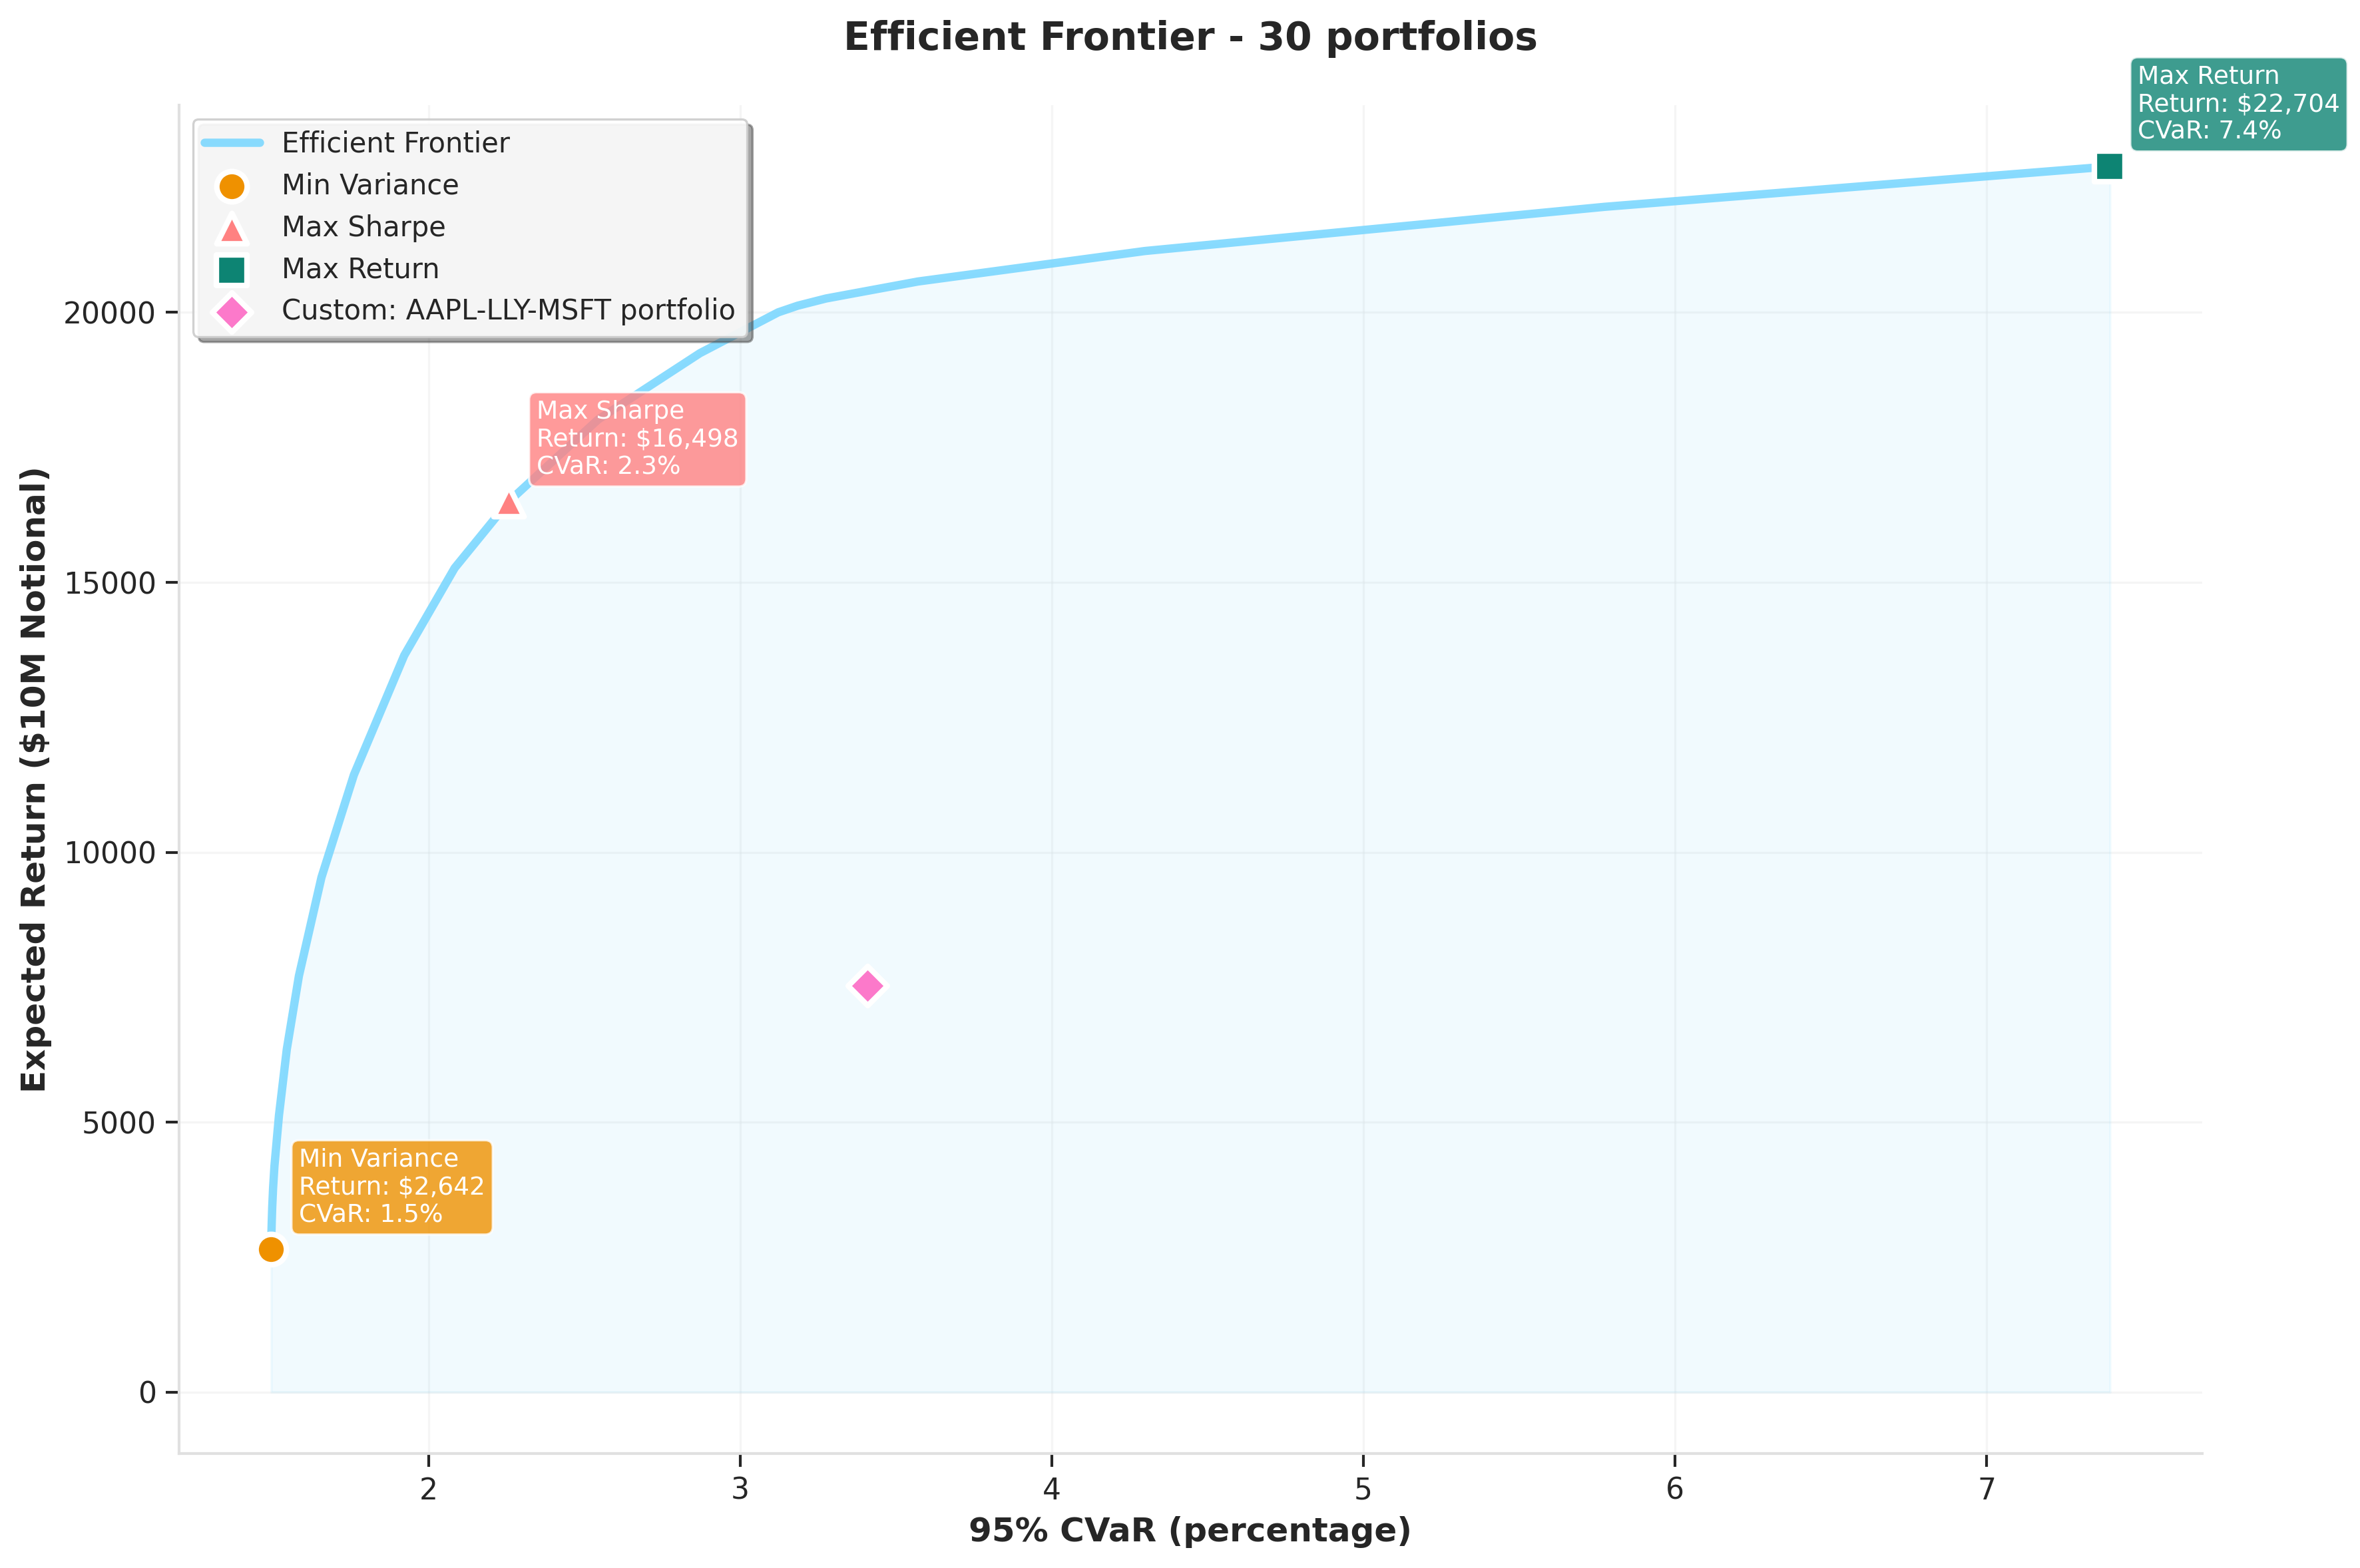

Efficient frontier analysis complete!


In [17]:
# Define solver settings
ef_solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Create efficient frontier and generate the plot
results_df, fig, ax = cvar_utils.create_efficient_frontier(
    ef_returns_dict,
    ef_cvar_params,
    ef_solver_settings,
    custom_portfolios_dict = ef_custom_portfolios_dict,
    ra_num = ef_risk_aversion_steps,
    min_risk_aversion = ef_min_risk_aversion_exp,
    max_risk_aversion = ef_max_risk_aversion_exp,
    save_path = None,
    show_discretized_portfolios = False, #optional to turn on, but very time consuming
    #discretization_params={
    #    "weight_discretization": 50,
    #    "min_weight": ef_cvar_params.w_min,
    #    "max_weight": ef_cvar_params.w_max
    #},
    print_portfolio_results = False,
    show_plot = True
)

<a id="rebalancing-strategies"></a>
## 2. Rebalancing Strategies

This notebook demonstrates dynamic portfolio rebalancing strategies using the core Mean-CVaR optimization module. Rebalancing adapts portfolio weights in response to market changes, aiming to maintain optimal performance while accounting for transaction costs and turnover constraints. In this example, we implement a simple transaction cost model: transaction_cost = transaction_cost_factor * turnover, with turnover $=\lVert w-w_{pre} \rVert_1$. 

We compare two rebalancing triggers:
- [Percentage change](#percentage-change): Reoptimize when portfolio value drops below a threshold.
- [Drift from optimal](#drift-from-optimal): Reoptimize when current weights deviate from optimal weights by a specified norm.

Both strategies are benchmarked against a buy-and-hold baseline, and we may evaluate performance using GPU (cuOpt) vs. CPU solvers.


In [18]:
from cufolio import rebalance

In [ ]:
# Global data settings.
# Define dataset paths and common parameters.
sp500_dataset_name = "sp500"
sp500_dataset_directory = f"../data/stock_data/{sp500_dataset_name}.csv"

# Settings for computing returns and scenario generation
rebal_returns_compute_settings = ReturnsComputeSettings(return_type='LOG', freq=1)
rebal_scenario_generation_settings = ScenarioGenerationSettings(
    num_scen=10000,
    fit_type='kde',
    kde_settings=KDESettings(bandwidth=0.01, kernel='gaussian', device='GPU'),
    verbose=False
)

In [20]:
# Define CVaR parameters for rebalancing with transaction costs and turnover constraints.
rebal_tc_cvar_params = CvarParameters(
    w_min=-0.3,
    w_max=0.8,
    c_min=0.1,
    c_max=0.4,
    L_tar=1.6,
    T_tar=0.5,        # Turnover constraint to limit trading activity.
    cvar_limit=None,
    risk_aversion=1,
    confidence=0.95,
)

## Strategy 1: Percentage Change Rebalancing
<a id='percentage-change'></a>

Re-optimization will be triggered if one of the following conditions hold: 
- the percent change of the portfolio value from the start of the testing period to the end drops below `pct_change_tolerance`;
- the cumulative percent change of the portfolio value since the *last postive* percent change backtest period drops below `pct_change_tolerance`

For example, we use a 21-day (one-month) look-forward window and 252-day (one-year) look-back window for rolling optimization, with cuOpt as the GPU solver. One may switch to a CPU solver but it will be much slower. 


BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.94
Total return: -3.72%
Data points collected: 441

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Percentage Change
Threshold: -0.005
Look-forward window: 21 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-02 | Event #1 | Portfolio value: $0.97
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-09-30 | Event #2 | Portfolio value: $1.05
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-11-30 | Event #3 | Portfolio value: $1.00
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #4 | Portfolio v

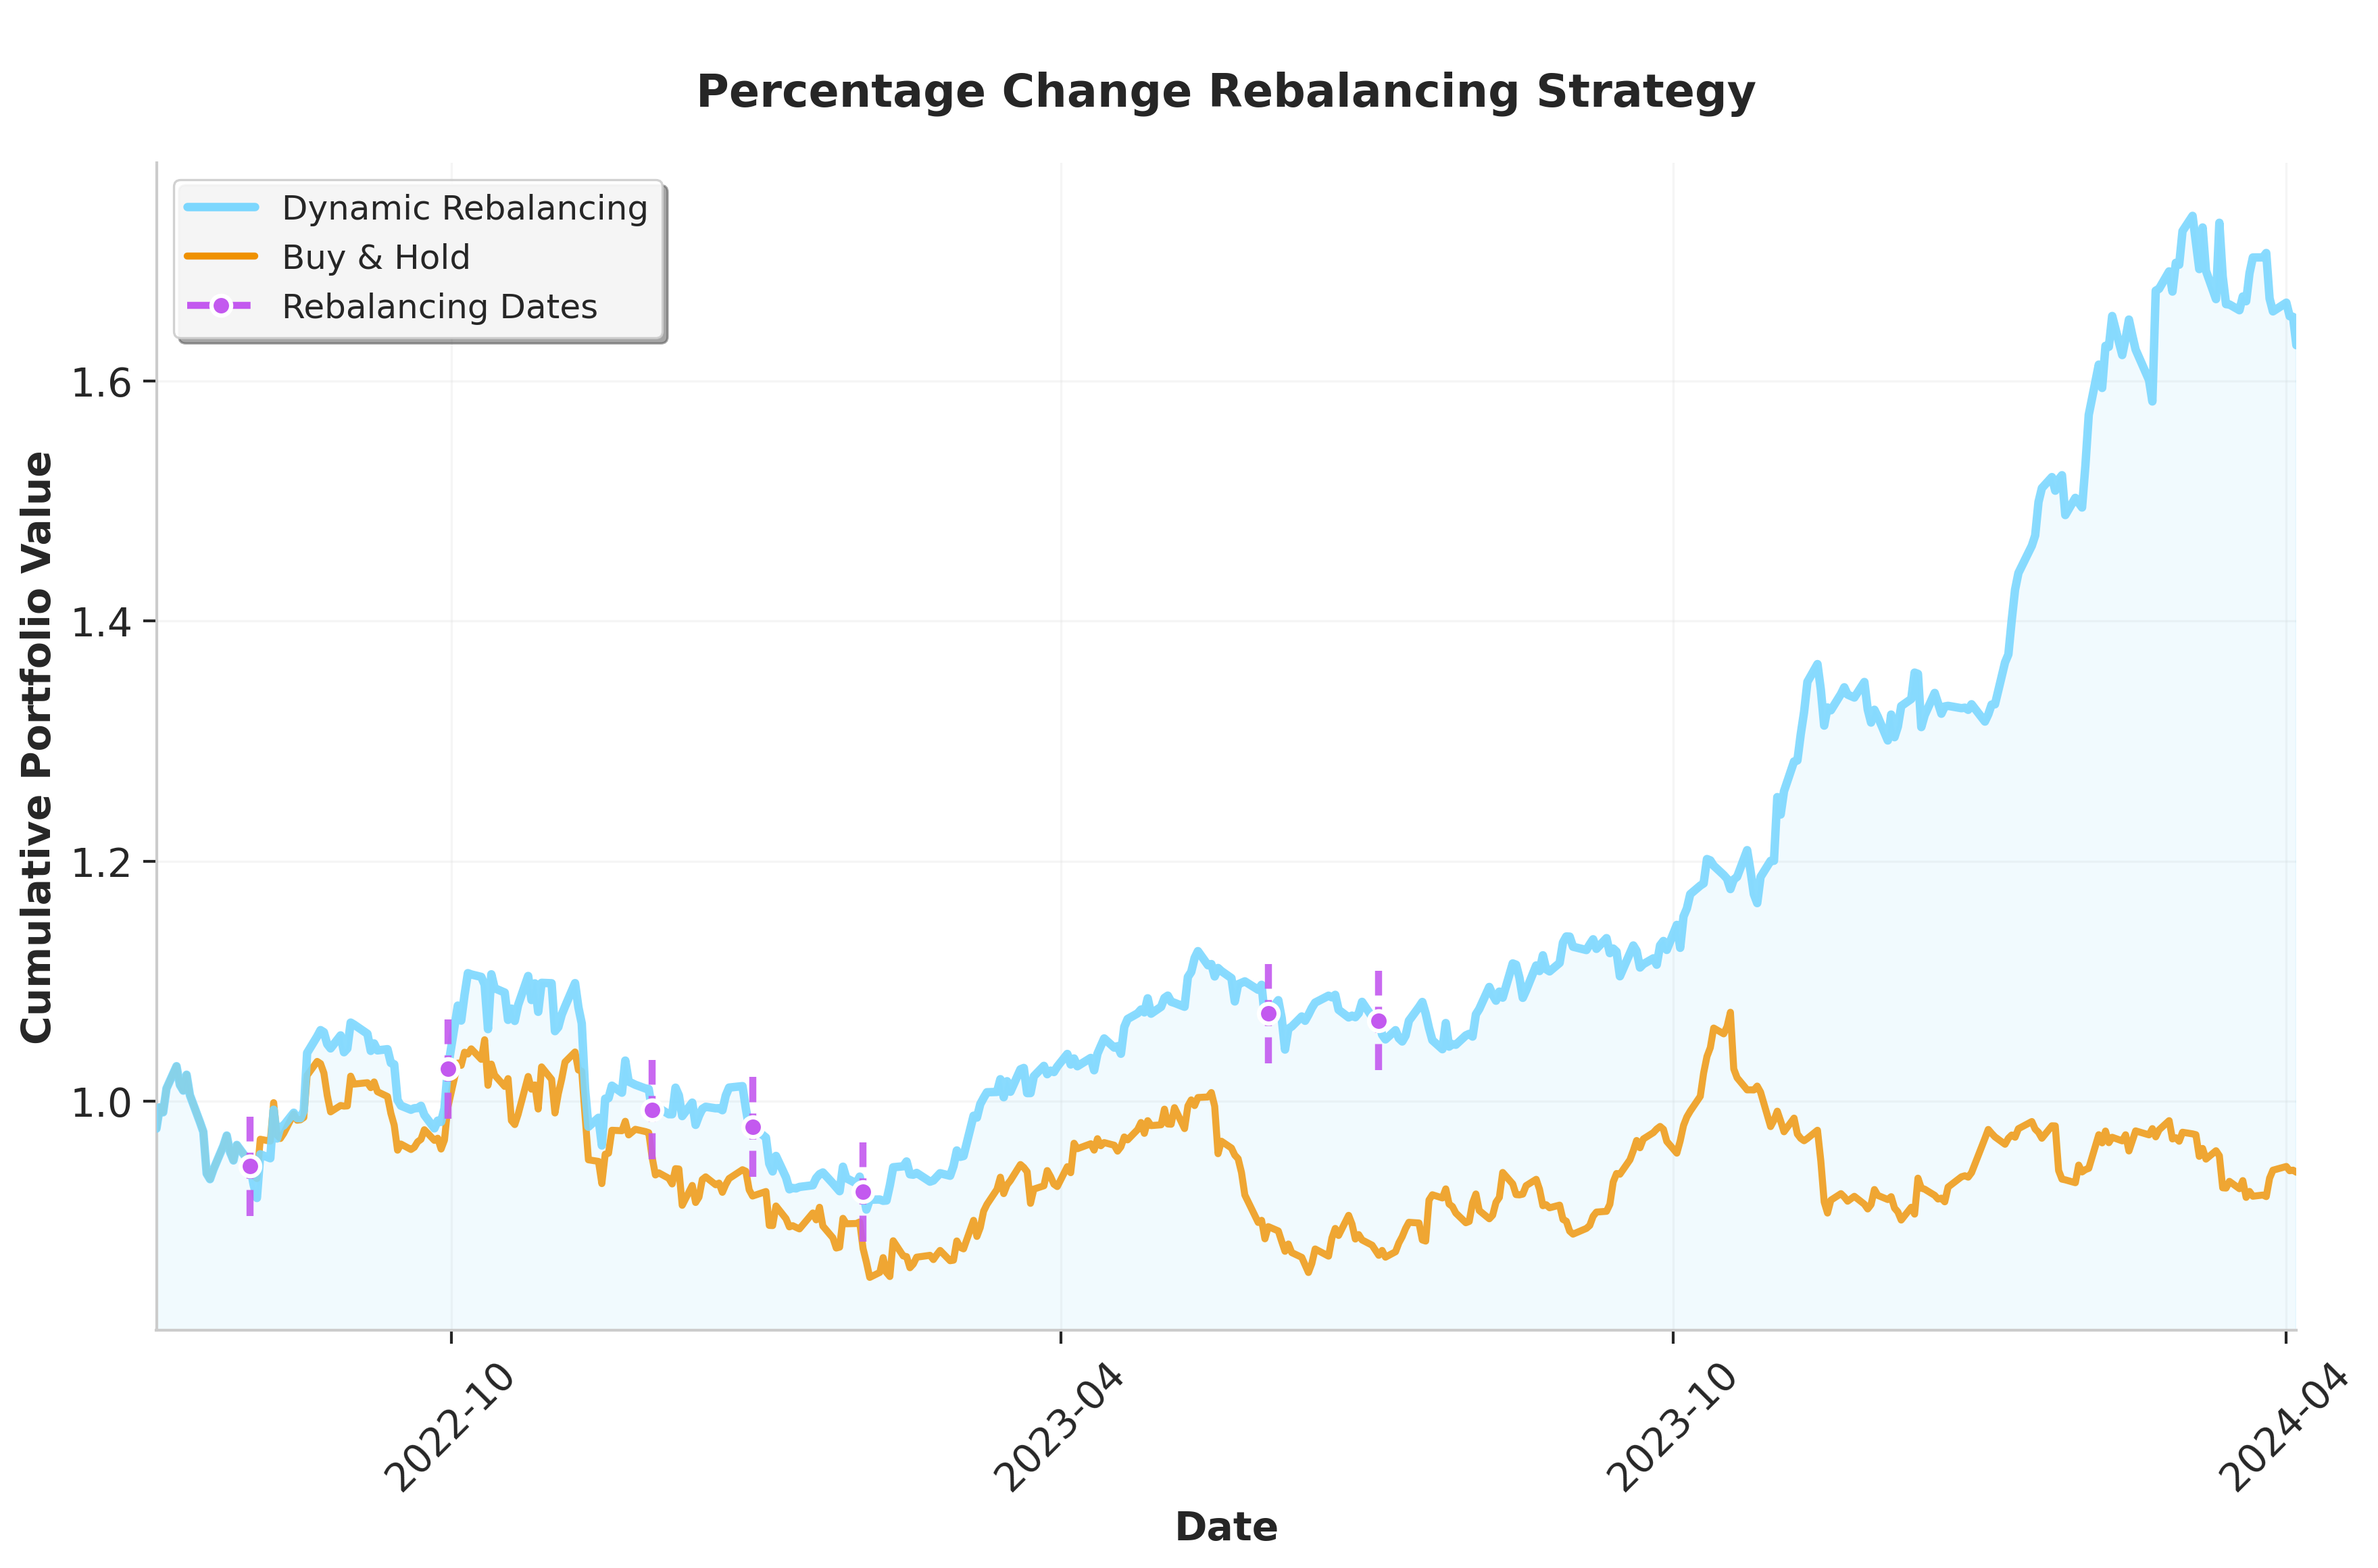

In [21]:
# Trading period and backtesting windows.
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-05-01"

rebal_look_back_window = 252       # Historical period for optimization (trading days).
rebal_look_forward_window = 21     # Out-of-sample testing period (trading days).

# Transaction cost parameters
transaction_cost_factor = 0.001

# Reoptimization trigger: percentage change threshold.
percent_change_tolerance = -0.005   # Reoptimize if portfolio value drops by 0.5%.
pct_change_re_optimize_criteria = {"type": "pct_change", "threshold": percent_change_tolerance}

# GPU solver configuration.
solver_settings = {'solver':cp.CUOPT, 'verbose': False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing with percentage change trigger.
pct_change_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=pct_change_re_optimize_criteria, #specify the re-optimization criteria
    print_opt_result = False
)

# Retrieve and plot optimization results.
pct_change_results_df, pct_change_re_optimize_dates, cumulative_portfolio_value_array = pct_change_rebalancing_obj.re_optimize(
                                                                                                                        transaction_cost_factor = transaction_cost_factor, \
                                                                                                                        plot_results=True, \
                                                                                                                        save_plot = True, \
                                                                                                                        results_dir = "../results/rebalancing_strategies"
                                                                                                                        )

## Strategy 2: Drift from Optimal Portfolio
<a id='drift-from-optimal'></a>
Portfolio value changes as the asset values in the portfolio changes. Over time, the portfolio composition will deviate from the original optimized portfolio. A re-optimization is triggered if the norm of the difference between current and optimal weights exceeds `drift_tolerance`, i.e. 
$$\lVert w_{cur} - w_{opt} \rVert_* > tol,$$
where:

- $w_{cur}$ = Current portfolio weights
- $w_{pre}$ = Optimal portfolio weights
- $tol$ = `drift_tolerance`
- Norm $*$: 1-norm (absolute differences) or 2-norm (Euclidean distance).

BASELINE (BUY & HOLD) ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Single optimization at start
Setting parameter log_to_console to false
Setting parameter method to 1

BASELINE COMPLETE
Final portfolio value: $0.86
Total return: -12.41%
Data points collected: 420

DYNAMIC REBALANCING ANALYSIS
Period: 2022-07-01 to 2024-05-01
Strategy: Drift From Optimal
Threshold: 0.05
Look-forward window: 42 days
Look-back window: 252 days
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-08-31 | Event #1 | Portfolio value: $1.00
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-10-31 | Event #2 | Portfolio value: $0.96
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2022-12-30 | Event #3 | Portfolio value: $0.89
Setting parameter log_to_console to false
Setting parameter method to 1
Rebalancing triggered on 2023-03-03 | Event #4 | Portfolio v

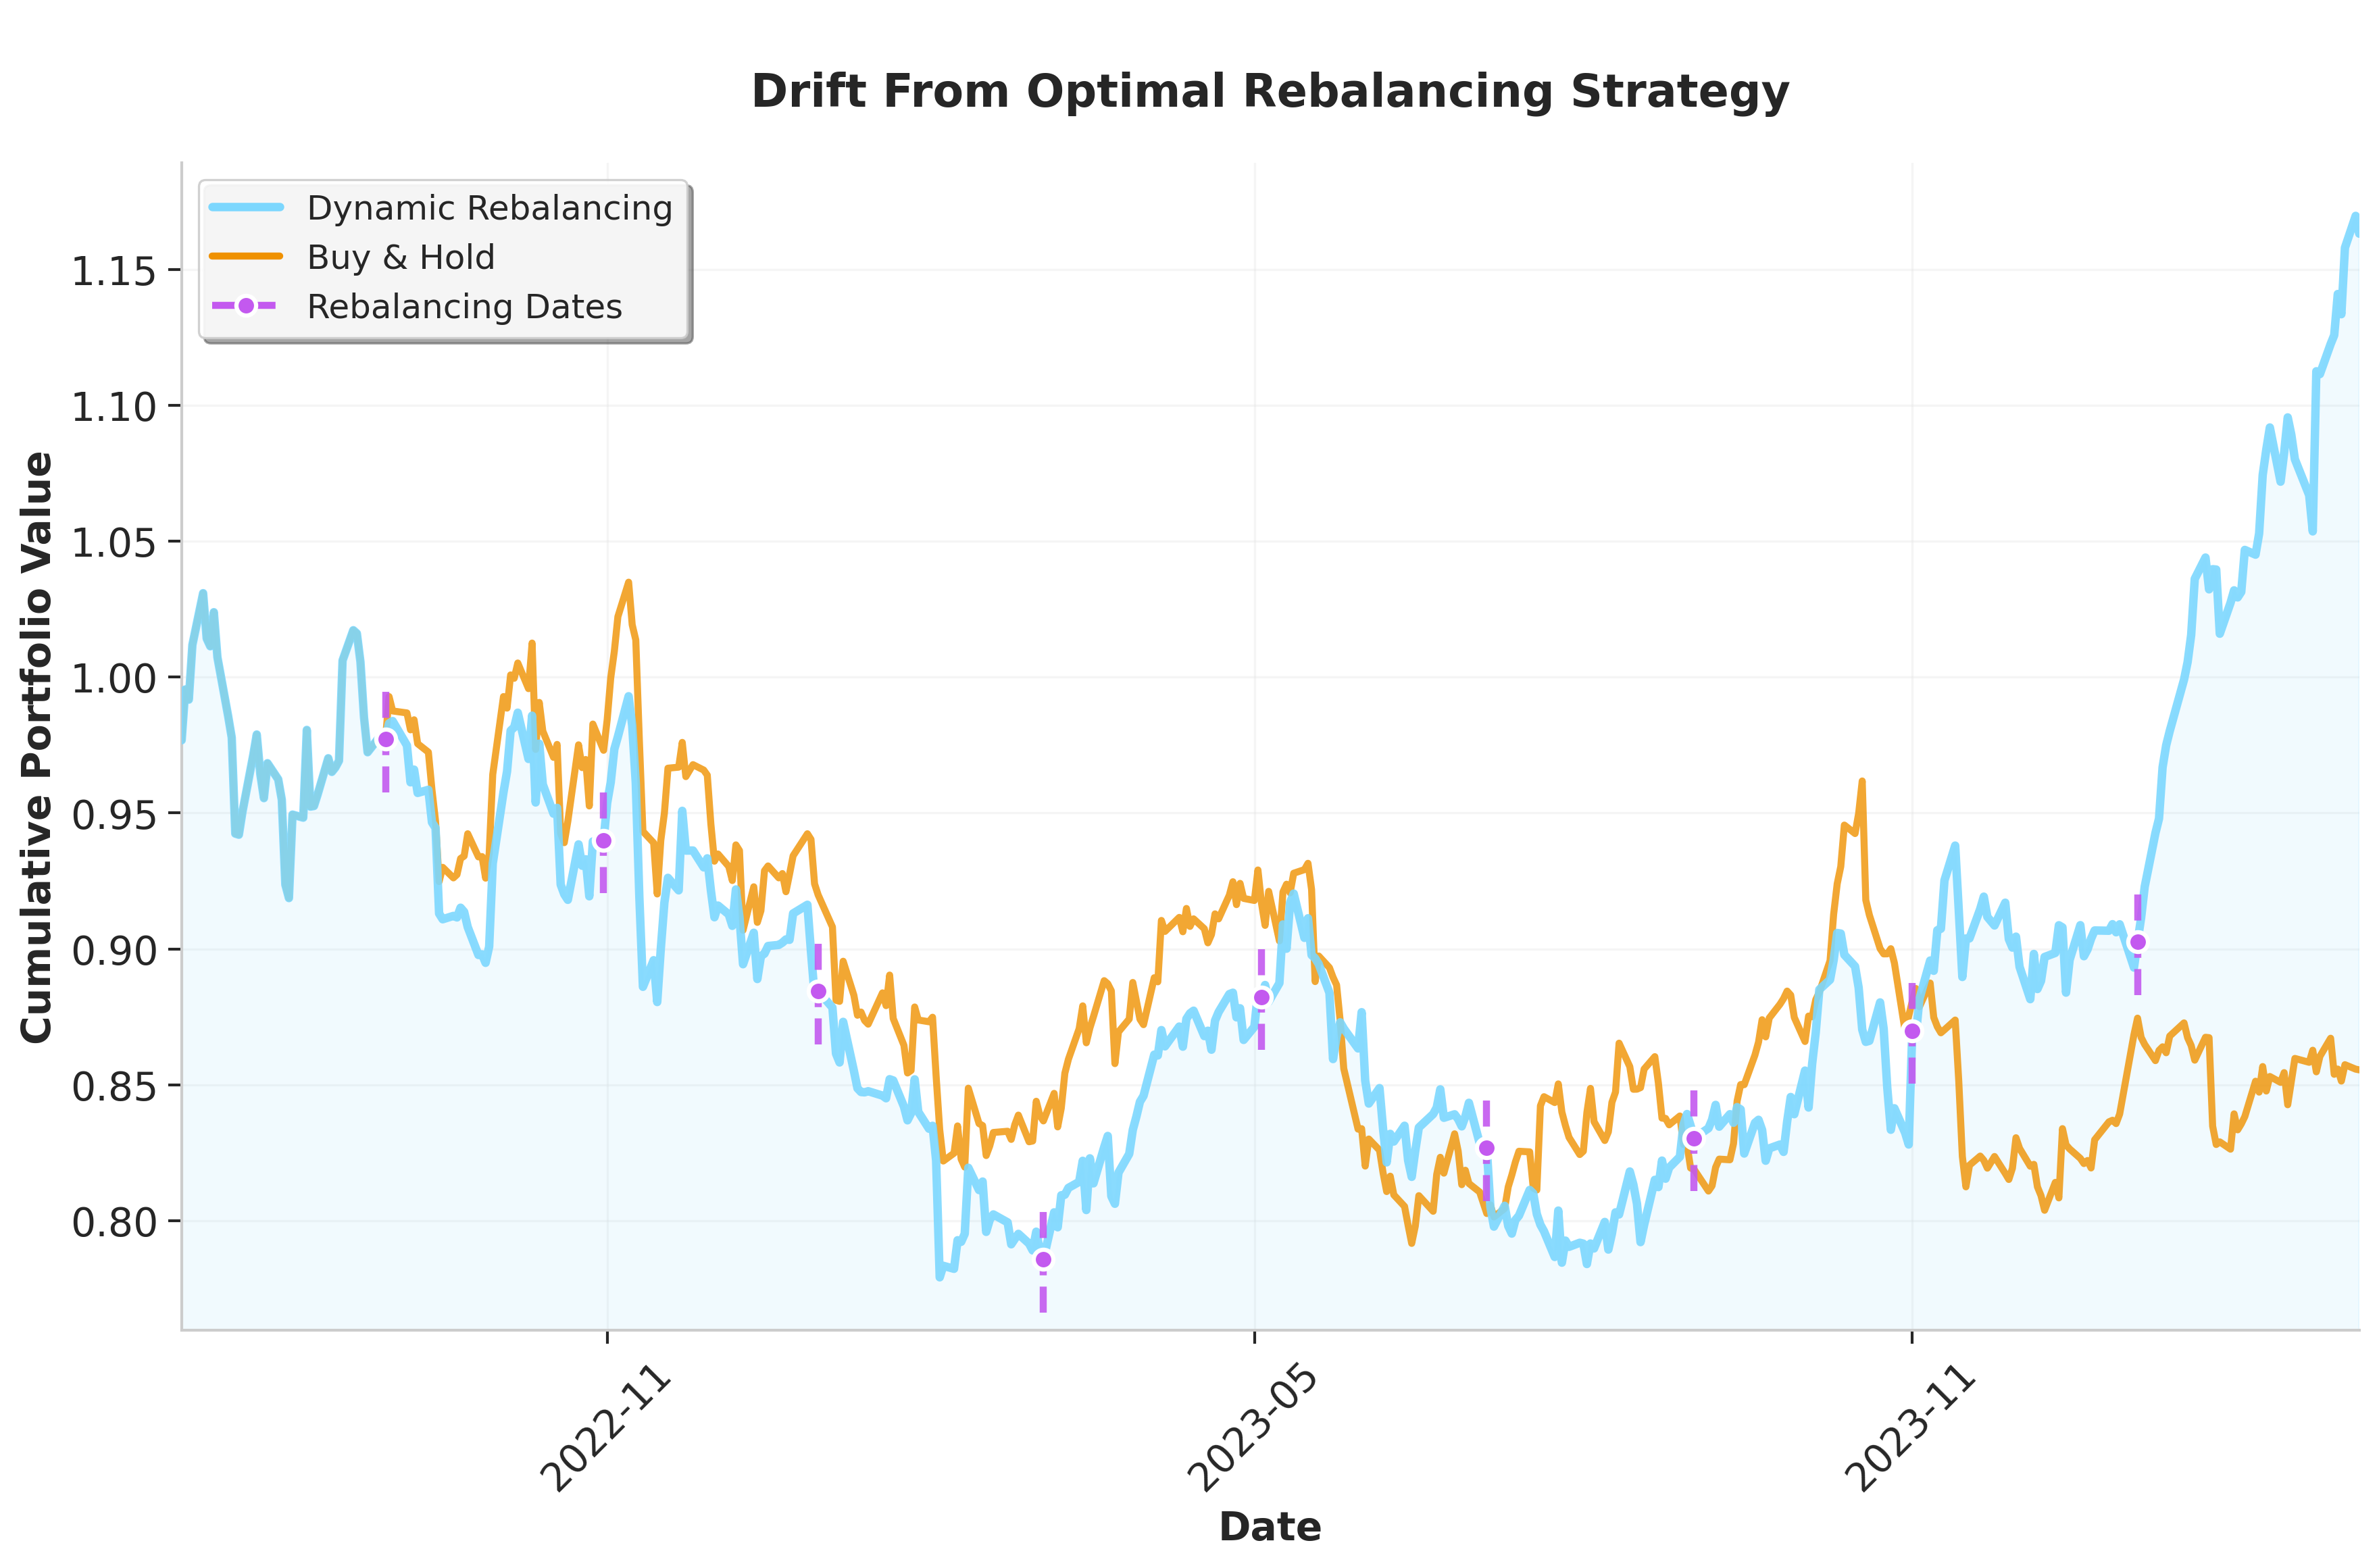

In [22]:
# --- Select Scenario for Rebalancing ---
selected_rebal_scenario_name = 'rebalancing_trading_period'
rebal_trading_start_date, rebal_trading_end_date = "2022-07-01", "2024-05-01"

# Look-back and look-forward windows for backtesting
rebal_look_back_window = 252       # Historical period used for optimization (trading days)
rebal_look_forward_window = 42     # Testing period (out-of-sample performance)

# Define drift tolerance threshold
drift_rebal_tolerance = 0.05        # Rebalance if weight deviation (L2 norm) exceeds tolerance

# Set re-optimization criteria for drift
drift_re_optimize_criteria = {
    "type": "drift_from_optimal",
    "threshold": drift_rebal_tolerance,
    "norm": 1,                # Using L2 norm
}

#GPU solver
solver_settings = {"solver": cp.CUOPT, "verbose": False, 'solver_method': 'PDLP'}

# Execute portfolio rebalancing
drift_rebalancing_obj = rebalance.rebalance_portfolio(
    dataset_directory=sp500_dataset_directory,
    returns_compute_settings = rebal_returns_compute_settings,
    scenario_generation_settings = rebal_scenario_generation_settings,
    trading_start=rebal_trading_start_date,
    trading_end=rebal_trading_end_date,
    look_forward_window=rebal_look_forward_window,
    look_back_window=rebal_look_back_window,
    cvar_params=rebal_tc_cvar_params,
    solver_settings = solver_settings,
    re_optimize_criteria=drift_re_optimize_criteria,
    print_opt_result=False
)

# Retrieve and plot results
drift_results_df, drift_re_optimize_dates, cumulative_portfolio_value_array = drift_rebalancing_obj.re_optimize(plot_results=True, save_plot = True, results_dir = "../results/rebalancing_strategies")

SPDX-FileCopyrightText: Copyright (c) 2023-2025 NVIDIA CORPORATION & AFFILIATES. All rights reserved. 

SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.